<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-IITMandi/blob/main/Module2/code/lab2_GoogleColab_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns             # statistical data visualization

In [4]:
pip install indsl # This will require restart of session

# Mount Google Drive

# TASK 1: Time Series Analysis

## Import the data from AirPassengers.csv file

In [5]:
path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module2/Data/AirPassengers.csv'

df = pd.read_csv(path)

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Rename the column names

In [6]:
df.columns = ['Date','Number of Passengers']

df.head()

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


##1.1 Visualize Time Series

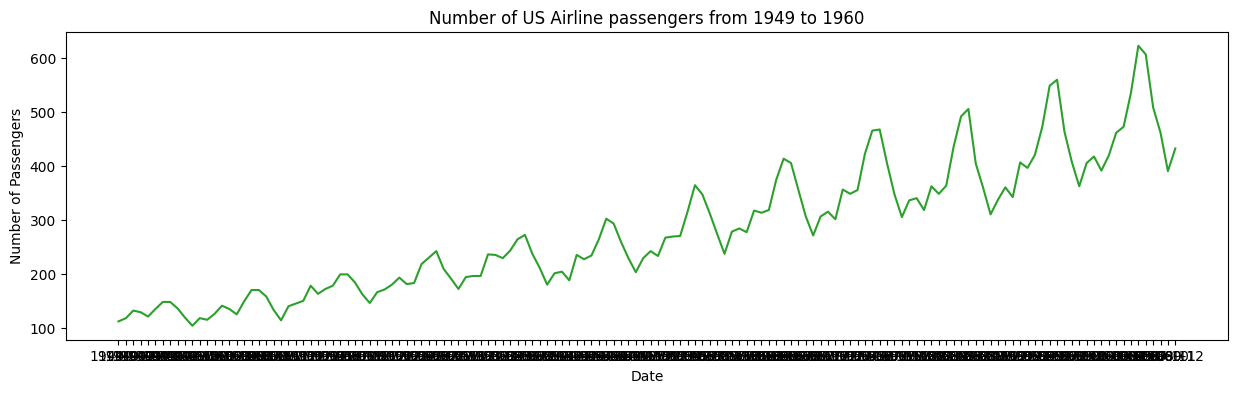

In [7]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:green')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()


plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')

Since all the values are positive, we can show this on both sides of the Y axis to emphasize the growth.

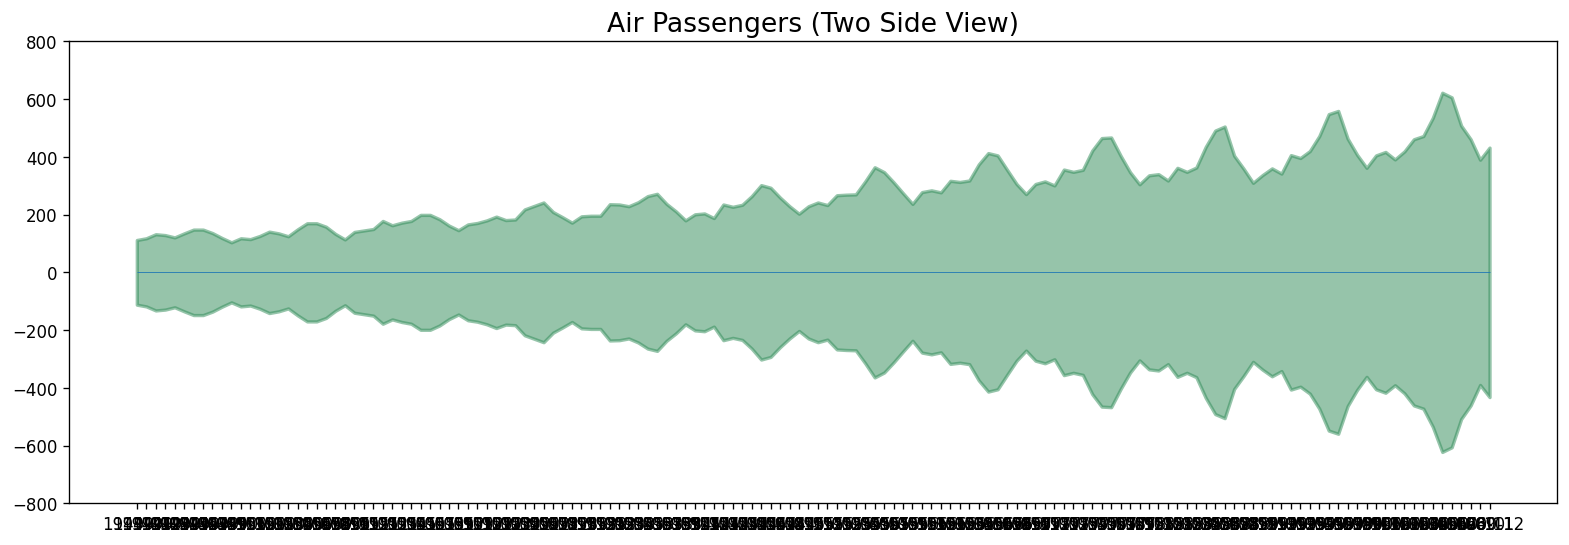

In [8]:
x = df['Date'].values
y1 = df['Number of Passengers'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')
plt.ylim(-800, 800)
plt.title('Air Passengers (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=.5)
plt.show()

##1.2 Pattern in Time Series

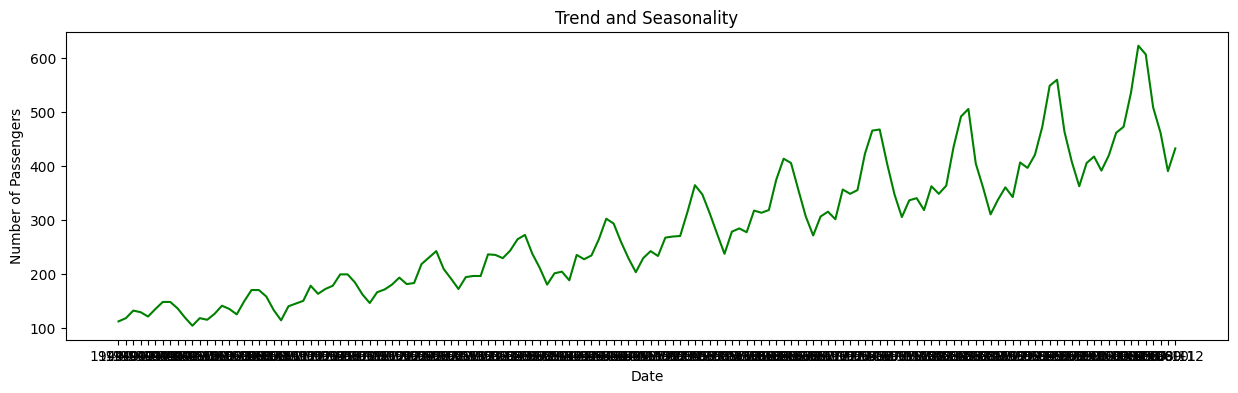

In [9]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='green')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()


plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Trend and Seasonality')

##1.3 Decompose Time Series

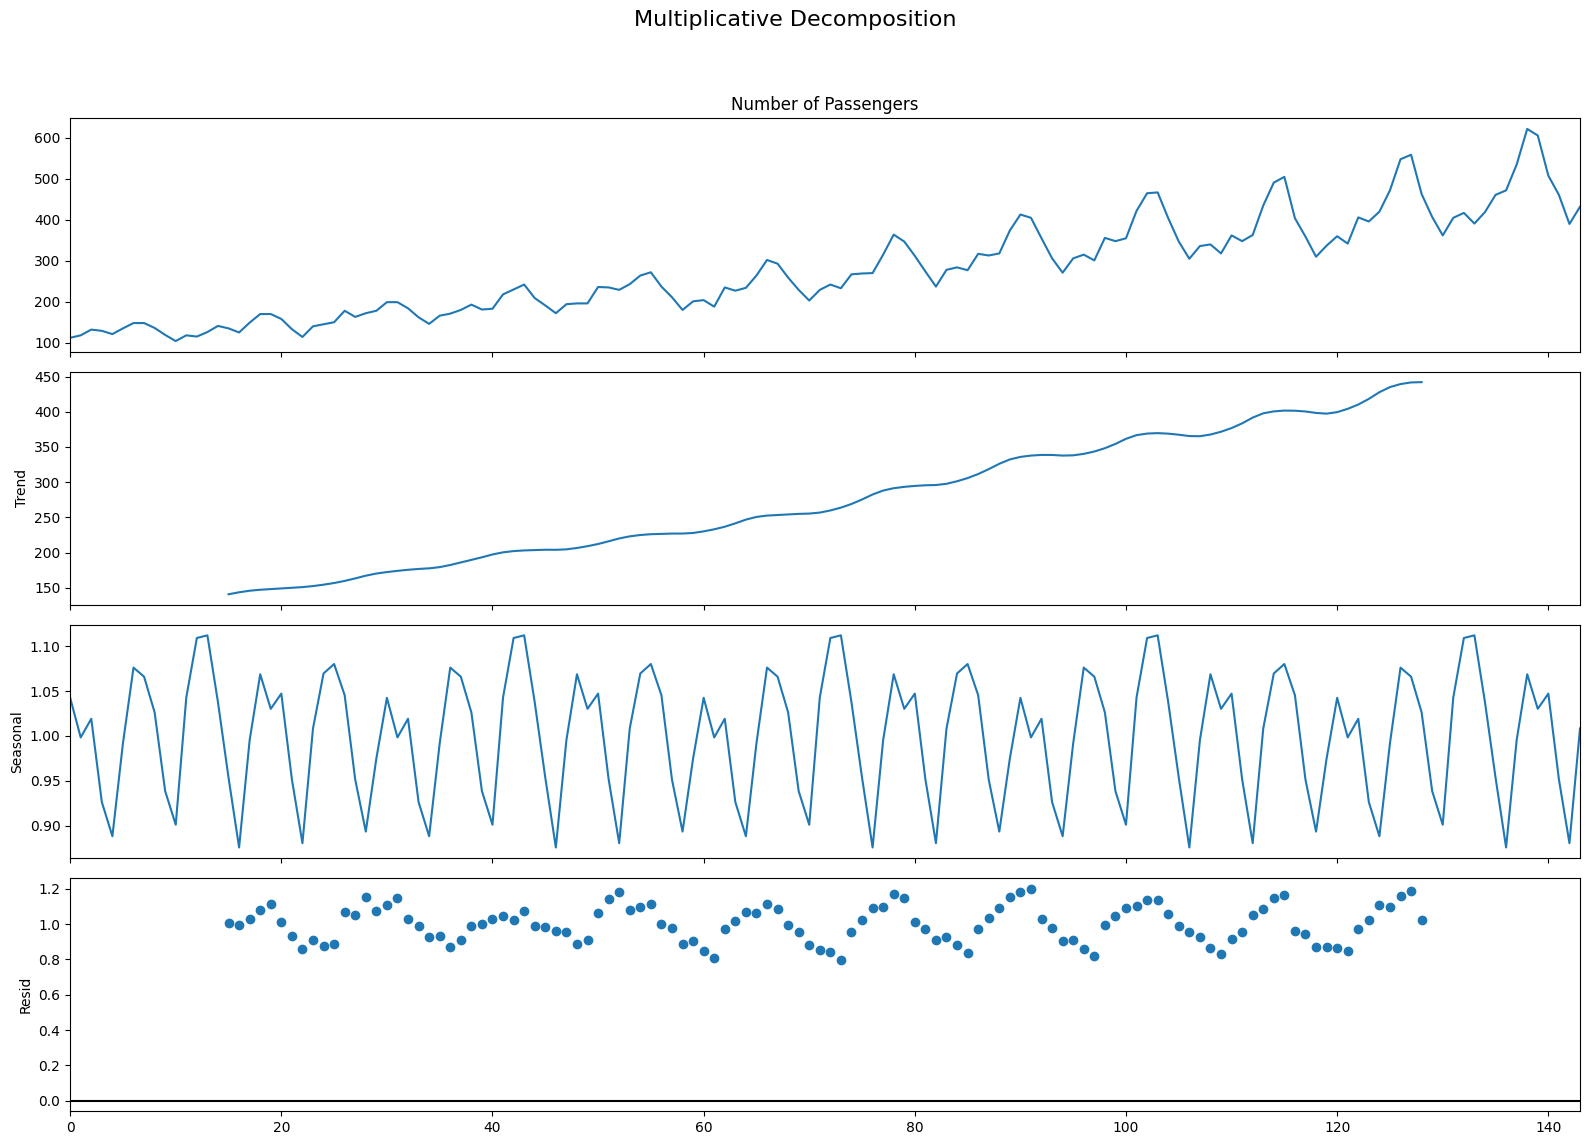

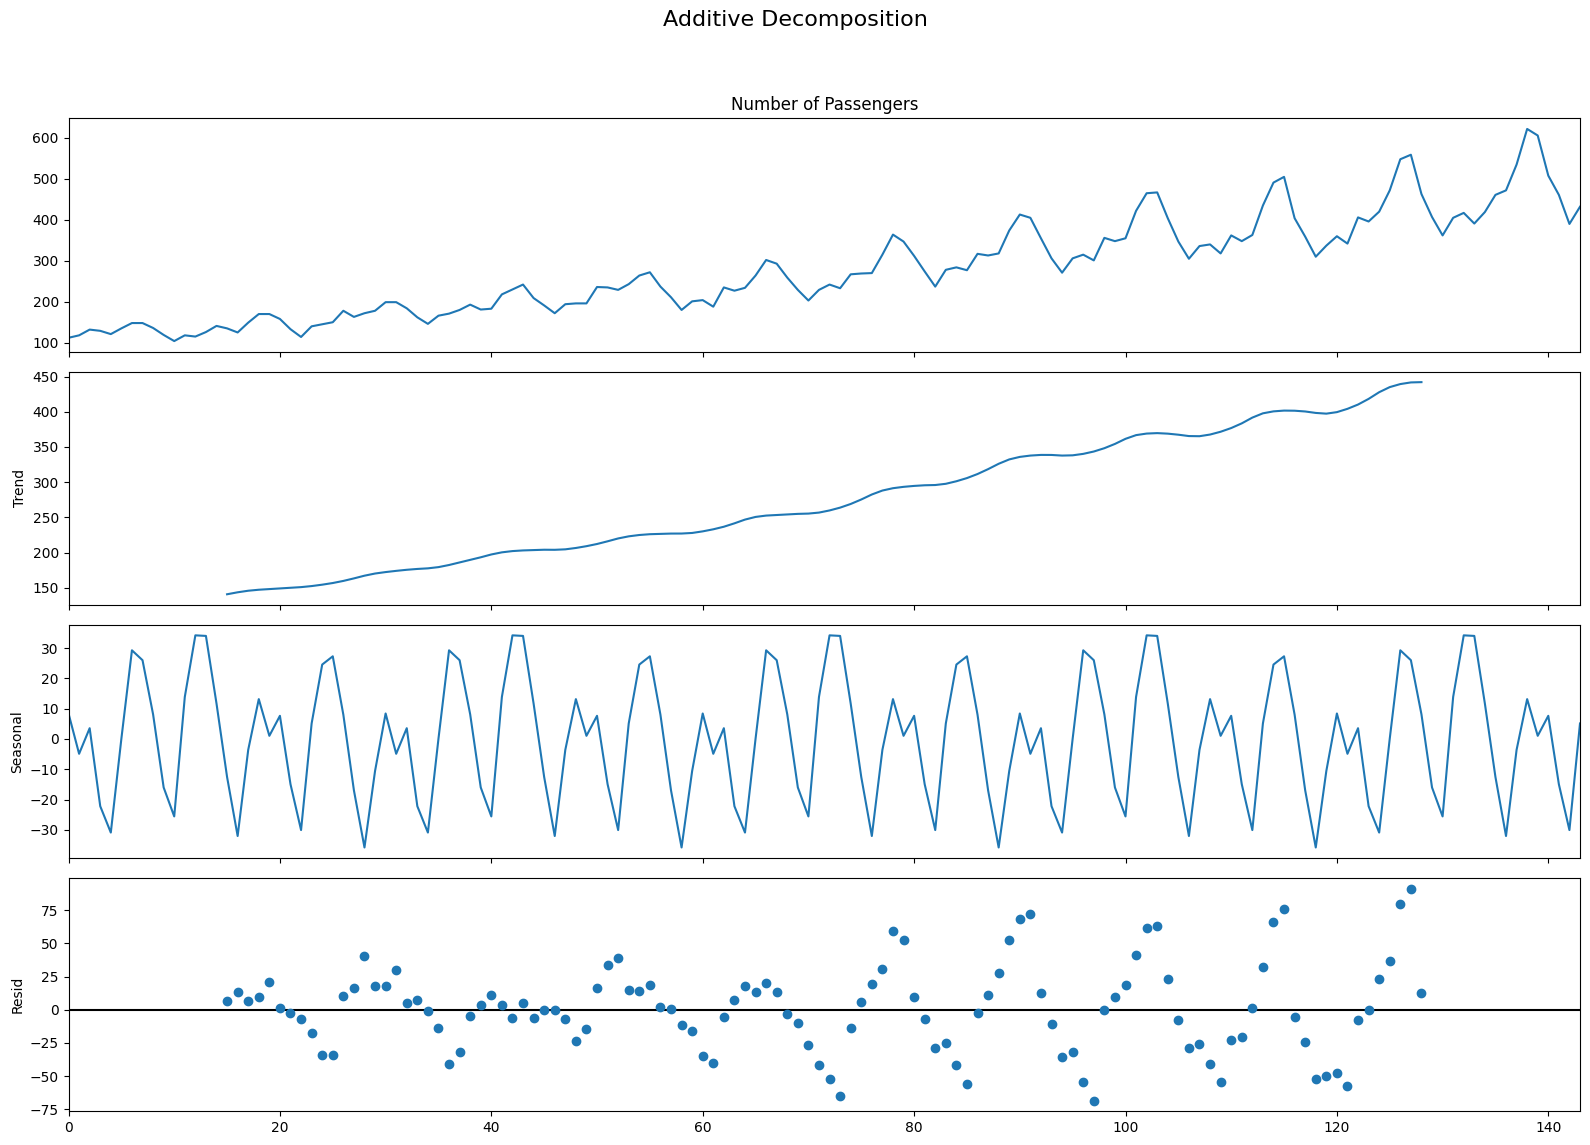

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
multiplicative_decomposition = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

##1.4 Test for Stationarity

### 1.4.1  Augmented Dickey Fuller test (ADF Test)

In [11]:
from statsmodels.tsa.stattools import adfuller

# Convert 'Month' column to datetime and set it as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Extract the time series
ts = df['Number of Passengers']

# Perform ADF test
adf_result = adfuller(ts)

# Print results
print("ADF Statistic: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

if adf_result[1] < 0.05:
    print("\nThe series is likely stationary (reject the null hypothesis).")
else:
    print("\nThe series is likely non-stationary (fail to reject the null hypothesis).")


ADF Statistic:  0.8153688792060498
p-value:  0.991880243437641
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598

The series is likely non-stationary (fail to reject the null hypothesis).


###1.4.2 Kwiatkowski-Phillips-Schmidt-Shin – KPSS test (trend stationary)

In [12]:
from statsmodels.tsa.stattools import kpss

# KPSS Test
kpss_result = kpss(ts, regression='c', nlags='auto')  # 'c' = constant (level stationarity)

# Print results
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value}")

if kpss_result[1] < 0.05:
    print("\nThe series is likely non-stationary (reject the null hypothesis).")
else:
    print("\nThe series is likely stationary (fail to reject the null hypothesis).")


KPSS Statistic: 1.6513122354165206
p-value: 0.01
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

The series is likely non-stationary (reject the null hypothesis).


/tmp/ipython-input-12-595243669.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts, regression='c', nlags='auto')  # 'c' = constant (level stationarity)


### 1.4.3 Philips Perron test (PP Test)

In [13]:
# First, install arch if not already installed
!pip install arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 14.3 MB/s eta 0:00:00


In [14]:
# Now import and run PP test
from arch.unitroot import PhillipsPerron

# Perform the PP test
pp_result = PhillipsPerron(ts)

# Display the result
print(pp_result.summary())

# get p-value
p_value = pp_result.pvalue

if p_value < 0.05:
    print("\nThe series is likely stationary (reject the null hypothesis).")
else:
    print("\nThe series is likely non-stationary (fail to reject the null hypothesis).")



     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.351
P-value                         0.605
Lags                               14
-------------------------------------

Trend: Constant
Critical Values: -3.48 (1%), -2.88 (5%), -2.58 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

The series is likely non-stationary (fail to reject the null hypothesis).


##1.5 Converting Non-Stationary time serie to Stationary (USING DIFFERENCING)

From Above stationary test we get the time series is non-stationary so we will perform the differencing and then check it

In [15]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller


ts = df['Number of Passengers']

# 1. First‐order differencing
ts_diff1 = ts.diff().dropna()

# 2. ADF test function
def adf_test(series, name="series"):
    result = adfuller(series)
    print(f"\n— ADF Test on {name} —")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p‑value       : {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"    Critical Value ({key}) : {val:.4f}")
    if result[1] < 0.05:
        print("  → Reject H₀: series is stationary")
    else:
        print("  → Fail to reject H₀: series is non‑stationary")

# 3. Run tests
adf_test(ts,       name="Original Series")
adf_test(ts_diff1,  name="First‑Differenced Series")

# 4. Second-order differencing
ts_diff2 = ts_diff1.diff().dropna()
adf_test(ts_diff2, name="Second‑Differenced Series")



— ADF Test on Original Series —
  ADF Statistic : 0.8154
  p‑value       : 0.9919
    Critical Value (1%) : -3.4817
    Critical Value (5%) : -2.8840
    Critical Value (10%) : -2.5788
  → Fail to reject H₀: series is non‑stationary

— ADF Test on First‑Differenced Series —
  ADF Statistic : -2.8293
  p‑value       : 0.0542
    Critical Value (1%) : -3.4817
    Critical Value (5%) : -2.8840
    Critical Value (10%) : -2.5788
  → Fail to reject H₀: series is non‑stationary

— ADF Test on Second‑Differenced Series —
  ADF Statistic : -16.3842
  p‑value       : 0.0000
    Critical Value (1%) : -3.4817
    Critical Value (5%) : -2.8840
    Critical Value (10%) : -2.5788
  → Reject H₀: series is stationary


## 1.6 Difference between white noise and a stationary series

<Axes: title={'center': 'Random White Noise'}>

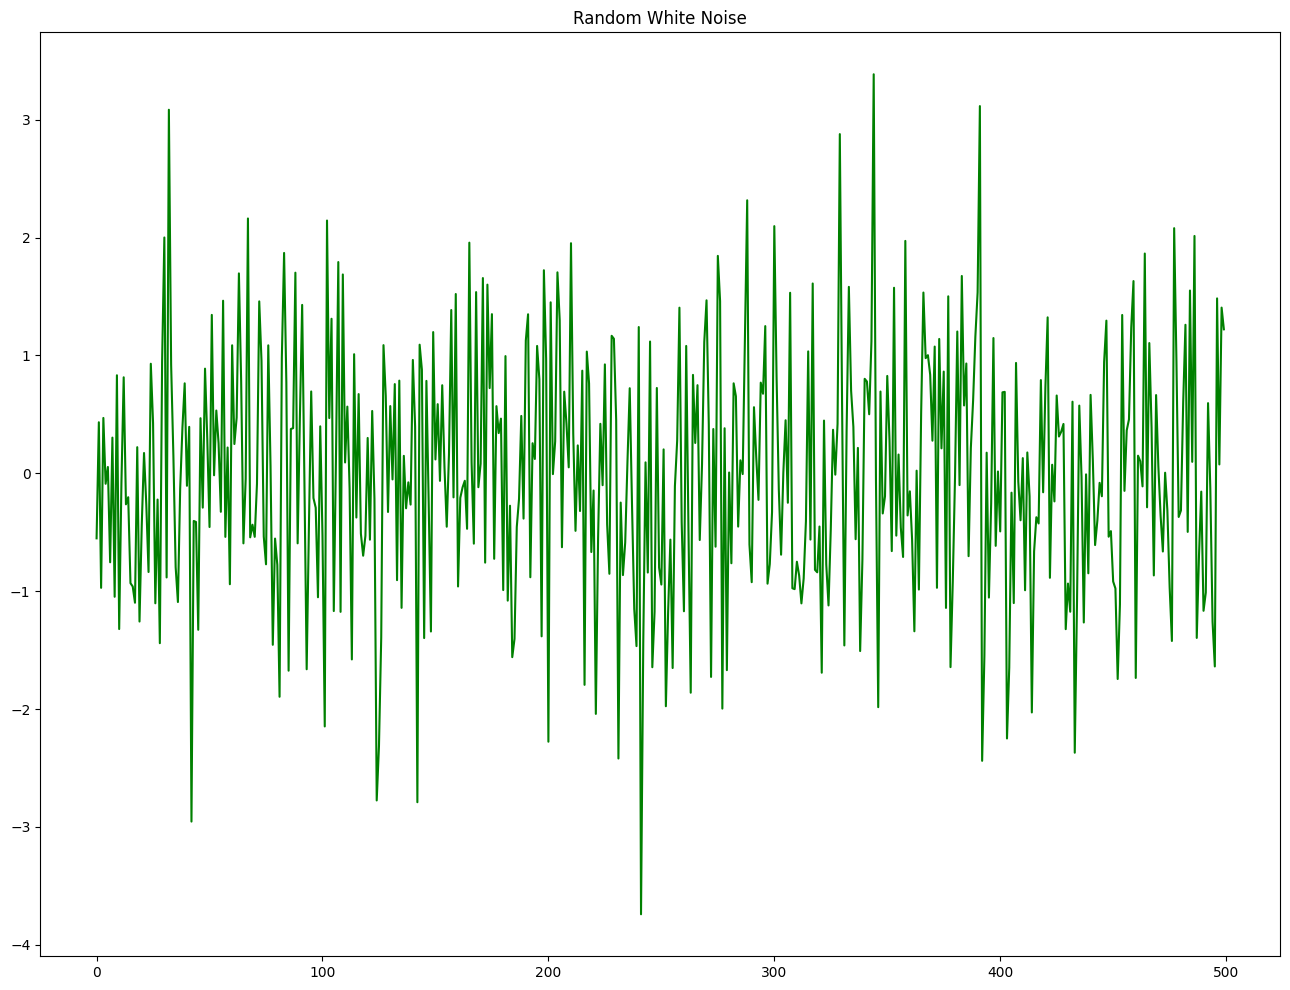

In [16]:
rand_numbers = np.random.randn(500)
pd.Series(rand_numbers).plot(title='Random White Noise', color='green')

##1.7 Test for Seasonality

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

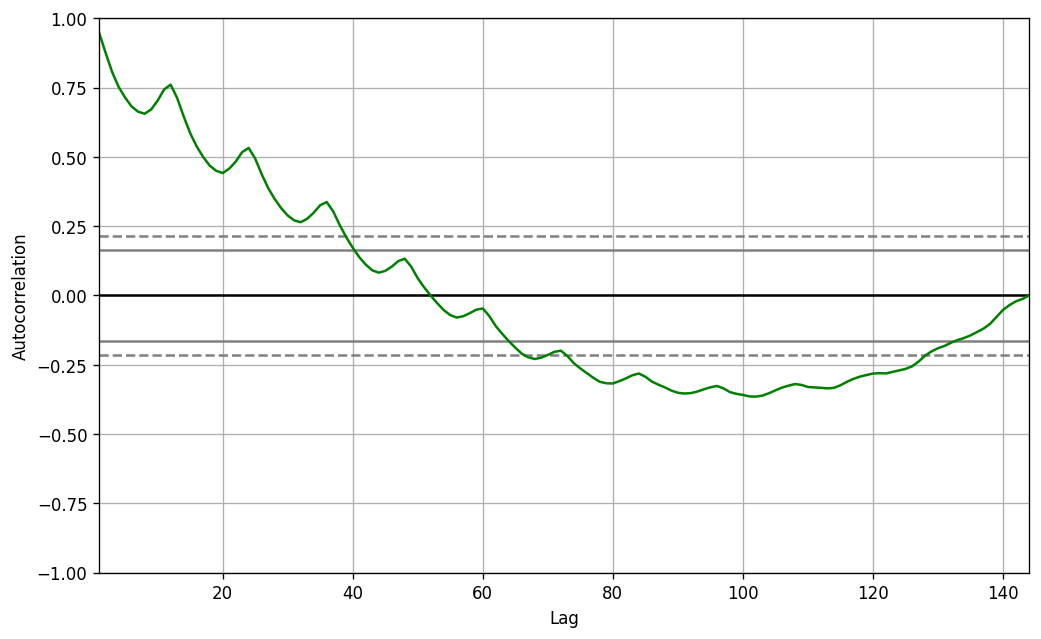

In [17]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(df['Number of Passengers'].tolist(),color='g')

## 1.8 Autocorrelation and Partial Autocorrelation Functions

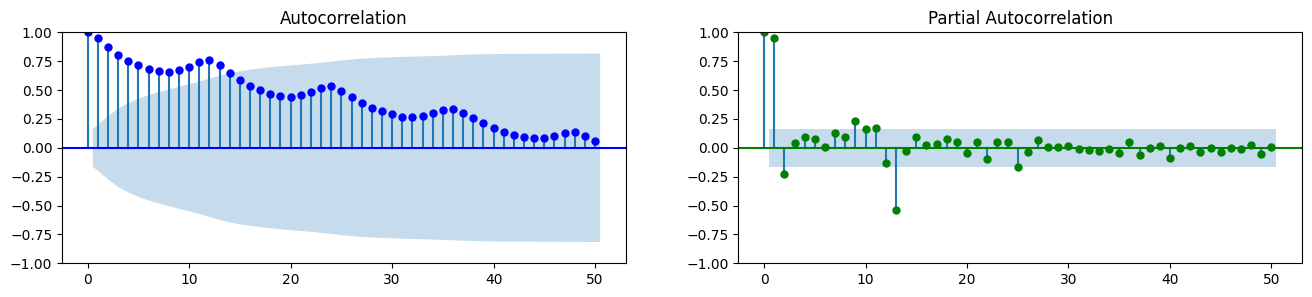

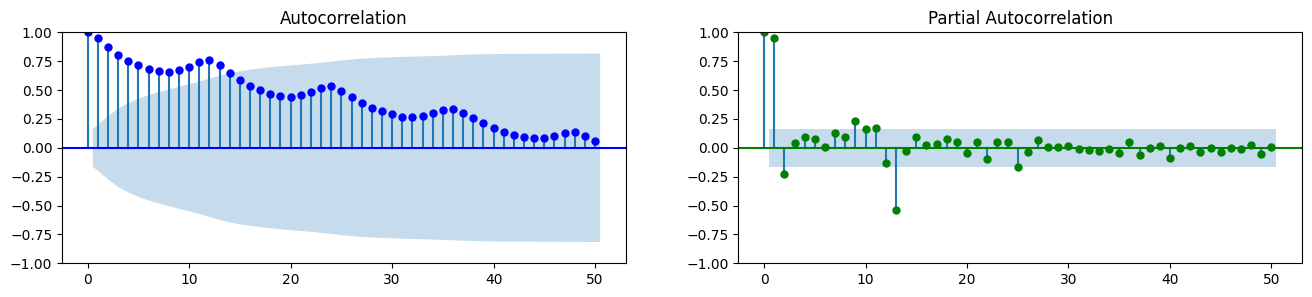

In [18]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Number of Passengers'].tolist(), lags=50, ax=axes[0],color='blue')
plot_pacf(df['Number of Passengers'].tolist(), lags=50, ax=axes[1],color='green')

##1.8 Lag plots

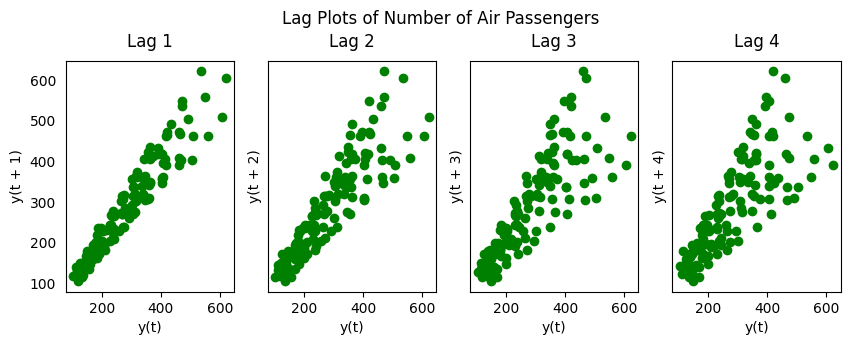

In [19]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df['Number of Passengers'], lag=i+1, ax=ax, c='green')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Number of Air Passengers', y=1.05)
plt.show()

##1.9 Granger Causality Test

In [20]:
from statsmodels.tsa.stattools import grangercausalitytests

# 1. Prepare the two‑column array for Granger testing:
#    - first column: the “target” series Yₜ (current passengers)
#    - second column: the “predictor” Xₜ (lag‑1 passengers)
df_gc = pd.concat([
    df['Number of Passengers'].rename('Y'),
    df['Number of Passengers'].shift(1).rename('X')
], axis=1).dropna()

# 2. Run Granger Causality up to 4 lags
#    This will test, for each lag k = 1…4, whether Xₜ₋ₖ → Yₜ
max_lag = 4
results = grangercausalitytests(df_gc[['Y','X']], maxlag=max_lag, verbose=True)

# 3. Interpret and print
print("Granger Causality Test Results (testing whether past 'X' helps predict 'Y')\n")
for lag in range(1, max_lag+1):
    p_value = results[lag][0]['ssr_ftest'][1]
    print(f"Lag = {lag}")
    print(f"  F‑test p‑value: {p_value:.4f}")
    if p_value < 0.05:
        print("  → p < 0.05: Reject H₀ → past 'X' Granger‑causes 'Y'.\n")
    else:
        print("  → p ≥ 0.05: Fail to reject H₀ → no evidence that past 'X' Granger‑causes 'Y'.\n")



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=16.8776 , p=0.0001  , df_denom=139, df_num=1
ssr based chi2 test:   chi2=17.2419 , p=0.0000  , df=1
likelihood ratio test: chi2=16.2728 , p=0.0001  , df=1
parameter F test:         F=16.8776 , p=0.0001  , df_denom=139, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7107  , p=0.0701  , df_denom=137, df_num=2
ssr based chi2 test:   chi2=5.5798  , p=0.0614  , df=2
likelihood ratio test: chi2=5.4722  , p=0.0648  , df=2
parameter F test:         F=11.3459 , p=0.0000  , df_denom=137, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9003  , p=0.4429  , df_denom=135, df_num=3
ssr based chi2 test:   chi2=2.8009  , p=0.4234  , df=3
likelihood ratio test: chi2=2.7732  , p=0.4279  , df=3
parameter F test:         F=8.5546  , p=0.0000  , df_denom=135, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.0180  , p=0.0955  

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Importing Data from csv file named NWH_filtered_main_data

In [21]:
# load the required data from csv file
data = pd.read_csv("https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module2/Data/NWH_filtered_main_data.csv") # Replace with your own csv file path

# Display head of the data

In [22]:
# print the head of the data
print(data.head())

    lat     lon          ym    BC_AOD    SU_AOD    DU_AOD  DU_AOD_pm25  \
0  29.0  79.375  1980-01-01  0.007333  0.021251  0.024280     0.014742   
1  29.0  79.375  1980-02-01  0.009356  0.036542  0.063201     0.037092   
2  29.0  79.375  1980-03-01  0.008504  0.028277  0.127768     0.074396   
3  29.0  79.375  1980-04-01  0.007283  0.017476  0.125042     0.072060   
4  29.0  79.375  1980-05-01  0.008863  0.024551  0.233929     0.130995   

        T2m       T850       T500       T250      QV2M      Q850      Q500  \
0  14.48235  283.03464  255.82576  226.09389  0.003412  0.002464  0.000421   
1  18.49313  285.73544  257.32068  225.02243  0.004069  0.003433  0.000646   
2  23.23214  289.20767  257.80237  225.67715  0.004338  0.003622  0.000881   
3  31.37173  297.09283  262.66602  227.76219  0.003997  0.003690  0.000592   
4  35.44920  300.63345  264.70566  233.86737  0.005358  0.004719  0.000763   

       Q250  elevation  
0  0.000046   215.8316  
1  0.000054   215.8316  
2  0.000048

### Define var

In [23]:
var = "T2m"
var_label = "Near-Surface Temperature (°C)"

In [24]:
# create a dataframe containing lat, lon, ym, var
var_df = data[["lat","lon","ym",var]]
var_df['ym'] = pd.to_datetime(var_df['ym'])

# Display var_df
display(var_df)

/tmp/ipython-input-24-2598639458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var_df['ym'] = pd.to_datetime(var_df['ym'])


,lat,lon,ym,T2m
0,29.0,79.375,1980-01-01,14.48235
1,29.0,79.375,1980-02-01,18.49313
2,29.0,79.375,1980-03-01,23.23214
3,29.0,79.375,1980-04-01,31.37173
4,29.0,79.375,1980-05-01,35.44920
...,...,...,...,...
51739,36.5,75.625,2023-08-01,3.42547
51740,36.5,75.625,2023-09-01,-0.32523
51741,36.5,75.625,2023-10-01,-6.78593
51742,36.5,75.625,2023-11-01,-12.34455


### Filter data for particular time range

In [25]:
# Filter var_df for specific Time Period
var_df = var_df[(var_df['ym'] >= '1980-01-01') & (var_df['ym'] <= '2023-12-31')]

### Now we extract Year and month from the time column named as ym

In [26]:
# Extract year and month from the observation date as new columns
var_df['year'] = var_df['ym'].dt.year
var_df['month'] = var_df['ym'].dt.month
var_df

,lat,lon,ym,T2m,year,month
0,29.0,79.375,1980-01-01,14.48235,1980,1
1,29.0,79.375,1980-02-01,18.49313,1980,2
2,29.0,79.375,1980-03-01,23.23214,1980,3
3,29.0,79.375,1980-04-01,31.37173,1980,4
4,29.0,79.375,1980-05-01,35.44920,1980,5
...,...,...,...,...,...,...
51739,36.5,75.625,2023-08-01,3.42547,2023,8
51740,36.5,75.625,2023-09-01,-0.32523,2023,9
51741,36.5,75.625,2023-10-01,-6.78593,2023,10
51742,36.5,75.625,2023-11-01,-12.34455,2023,11


### Now we will group the value by lat-lon

In [27]:
# Group locations by lat-lon and collect observation values to NumPy array
var_group_df = var_df\
    .groupby(['lat', 'lon'])[var]\
    .apply(np.array)\
    .reset_index() # flatten the DataFrame

# Display the grouped var_df
display(var_group_df)

,lat,lon,T2m
0,29.0,79.375,"[14.482349999999997, 18.493130000000008, 23.23..."
1,29.0,80.000,"[14.271299999999997, 18.06777, 22.866700000000..."
2,29.5,78.750,"[13.447080000000028, 17.157100000000014, 21.27..."
3,29.5,79.375,"[10.736379999999995, 13.711659999999997, 17.64..."
4,29.5,80.000,"[9.051720000000046, 11.70867000000004, 15.6457..."
...,...,...,...
93,36.0,76.250,"[-24.612979999999965, -21.47763999999998, -18...."
94,36.5,73.750,"[-16.592600000000004, -14.240849999999966, -9...."
95,36.5,74.375,"[-17.561669999999964, -15.41459999999995, -11...."
96,36.5,75.000,"[-19.73681999999997, -17.105169999999987, -13...."


### Extract the T2m list for one lat-lon
(Note: For multiple location you can make use of loop)

In [28]:
# build the mask
mask = (var_group_df["lat"] == 29.0) & (var_group_df["lon"] == 79.375)

# select the list of T2m values
t2m_list = var_group_df.loc[mask, "T2m"].iloc[0]

len(t2m_list)

528

# TASK 3: Change Point Detection for Time Series Analysis

In [29]:
# install ruptures library
! pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:00


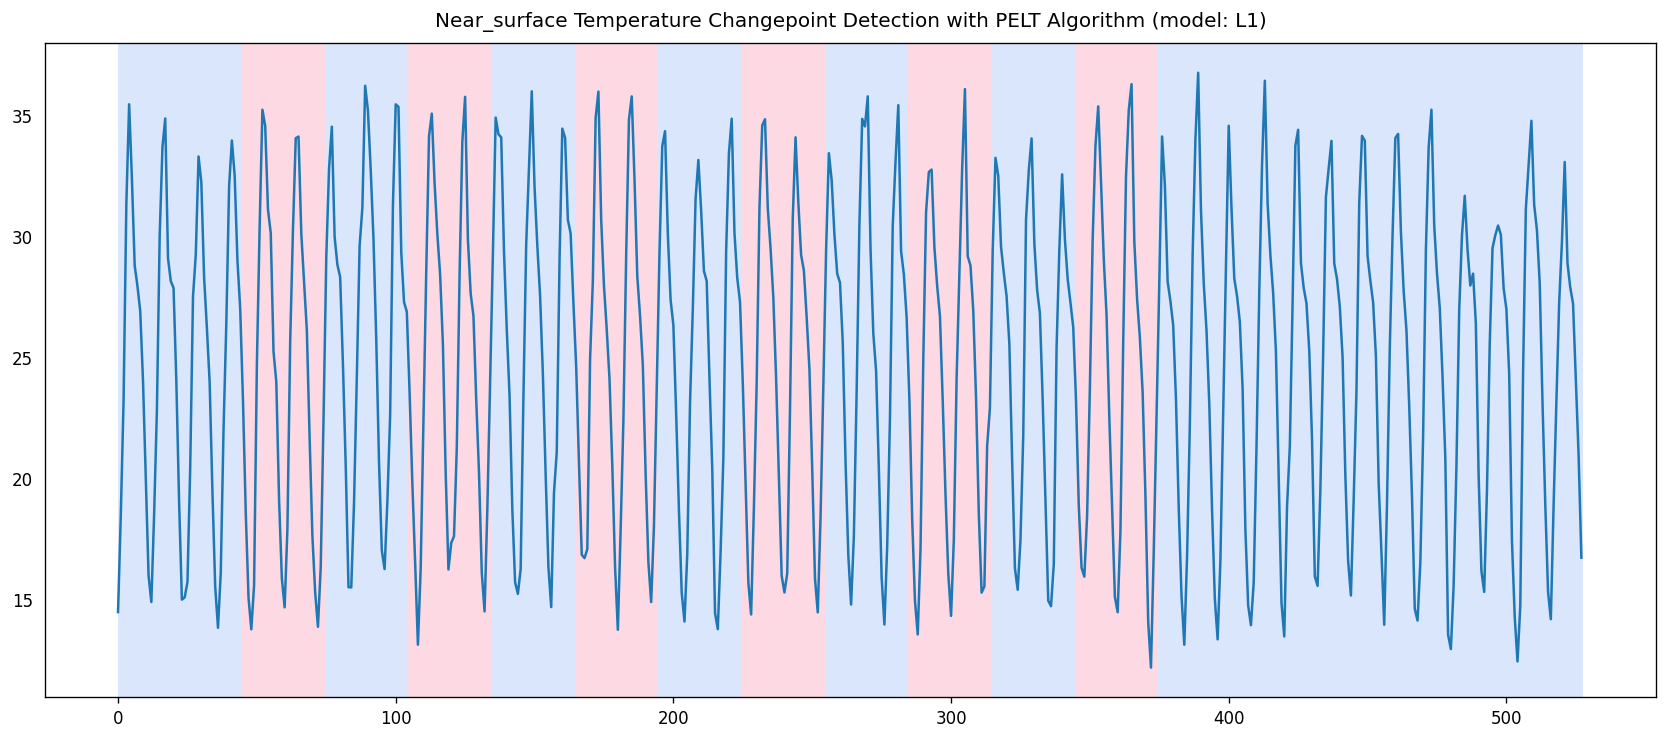

In [30]:
import matplotlib.pyplot as plt
import ruptures as rpt

def rpt_display(points, changepoints, col_name, method, model):
    rpt.display(points, changepoints, figsize=(14, 6))
    plt.title(f'{col_name} Changepoint Detection with {method} Algorithm (model: {model})');

points = t2m_list

model = 'l1'
algo = rpt.Pelt(model, min_size=24).fit(points)
changepoints = algo.predict(pen=5)
rpt_display(points, changepoints, 'Near_surface Temperature', 'PELT', 'L1')

/usr/local/lib/python3.11/dist-packages/indsl/equipment/volume_vessel.py:32: IndslUserWarning: Couldn't import fluids.numba_vectorized: No module named 'fluids'. Default to import fluids.vectorized.
  warnings.warn(
/tmp/ipython-input-31-3082571203.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index = pd.date_range(start=start, periods=periods, freq="M")


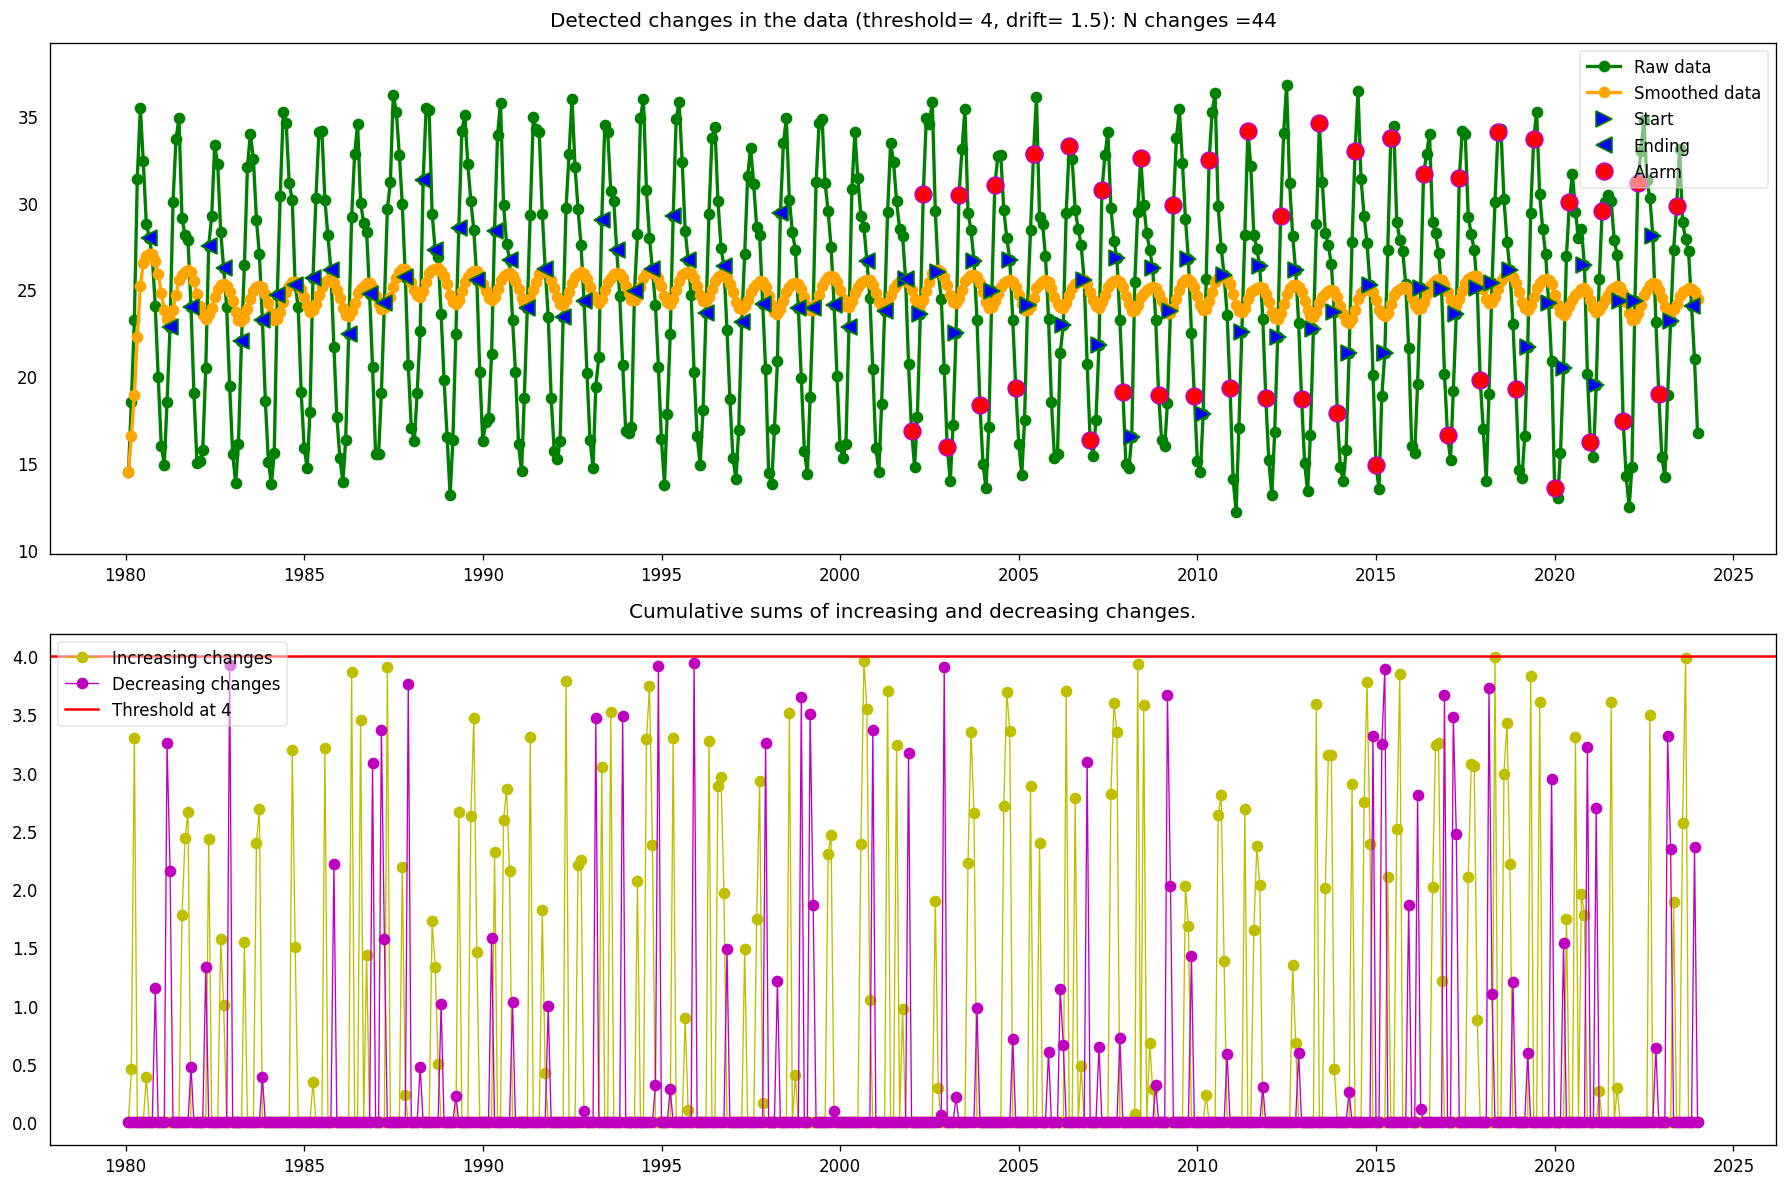

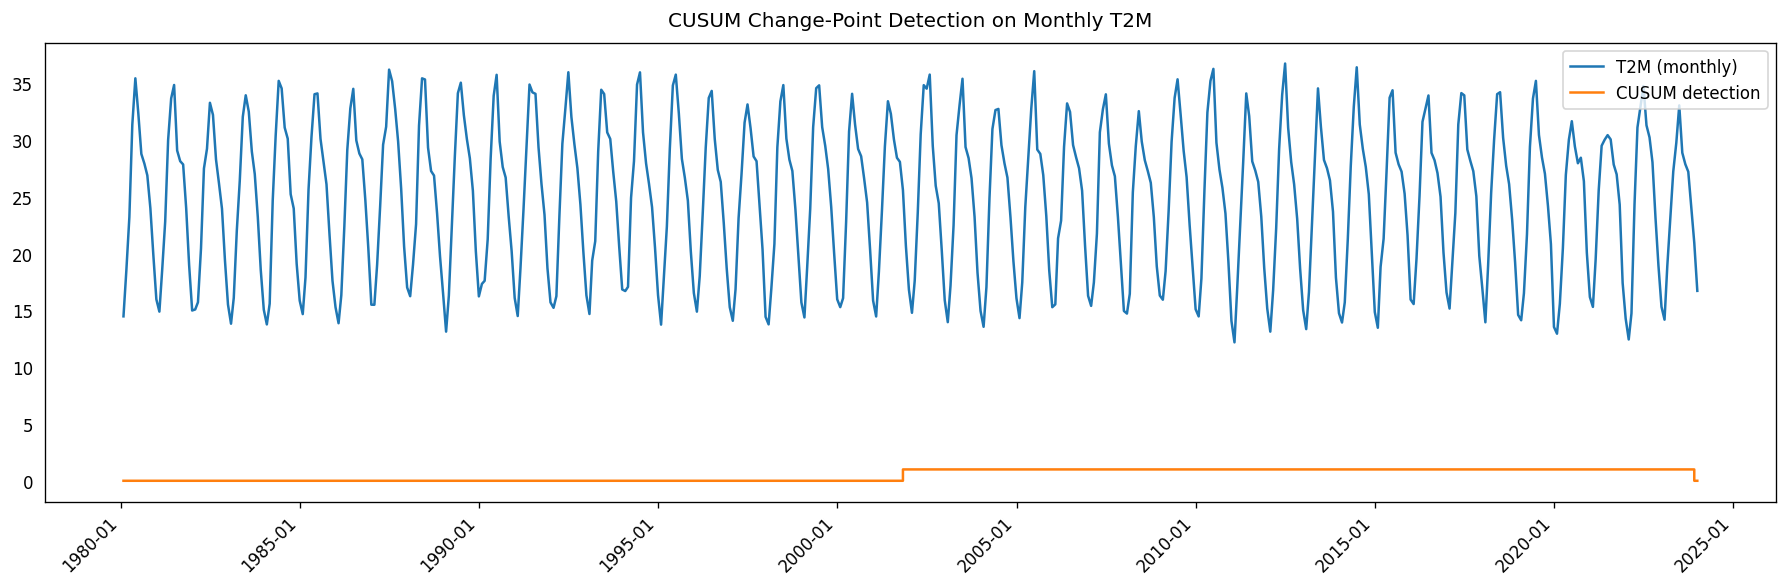

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.dates import DateFormatter
from indsl.detect.cusum import Cusum

# Suppose you have:
# t2m_list = [...]  # length 528, monthly T2M from Jan 1980 to Dec 2023

# create a monthly datetime index
start = "1980-01"
periods = len(t2m_list)  # should be 528
index = pd.date_range(start=start, periods=periods, freq="M")

# build the pandas Series
t2m_series = pd.Series(t2m_list, index=index, name="T2M")

# ——— Run CUSUM detection ———
# adjust threshold/drift if needed for your data characteristics
cusum_obj = Cusum(
    t2m_series,
    threshold=4,         # sensitivity threshold
    drift=1.5,           # drift parameter
    detect="both",       # detect upward and downward shifts
    predict_ending=True  # flag to extend final segment
)

# this will plot the intermediate CUSUM accumulation curves
res_binary = cusum_obj.cusum(plot_cusum=True)

# ——— Plot time series + binary detection result ———
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(t2m_series, label="T2M (monthly)")
ax.plot(res_binary, label="CUSUM detection", drawstyle="steps-post")
ax.set_title("CUSUM Change-Point Detection on Monthly T2M")
ax.legend(loc="best")

# Format the x‐axis to show Year‐Month
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()


Using Sliding Window approach using Standard deviation as cost function

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# --------------------------------------------------------------
# 1. Load your data into a DataFrame (adjust the path as needed)
# --------------------------------------------------------------
# Assuming your CSV has columns: lat, lon, ym (YYYY-MM-DD), T2m
df = var_df.copy()

# --------------------------------------------------------------
# 2. Parameters for sliding‐window change‐point detection
# --------------------------------------------------------------
window_size = 12  # number of months in each window
threshold_factor = 2.0  # sensitivity factor for SD threshold

# --------------------------------------------------------------
# 3. Helper function: compute windowed standard deviations & change points
# --------------------------------------------------------------
def compute_window_sds_and_cps(values, window_size, threshold_factor):
    """
    Given a series `values`, compute the sliding‐window standard deviations (costs)
    and detect change points when SD > (mean_SD + threshold_factor * std_SD).

    Returns:
      - window_sds: array of length (N - window_size + 1) with each window's SD
      - cp_idxs: list of integer indices (in the original series) flagged as change points
      - thr: the threshold used to declare a change point
    """
    n = len(values)
    n_windows = n - window_size + 1
    window_sds = np.zeros(n_windows)

    # 1. Compute SD for each window
    for i in range(n_windows):
        window_vals = values[i : i + window_size]
        window_sds[i] = np.std(window_vals)

    # 2. Define threshold: mean_SD + threshold_factor * std_SD
    mean_sd = window_sds.mean()
    std_sd = window_sds.std()
    thr = mean_sd + threshold_factor * std_sd

    # 3. Identify change windows where SD > thr
    #    We'll mark the center of each window as a change point index.
    cp_idxs = []
    half_win = window_size // 2
    for i in range(n_windows):
        if window_sds[i] > thr:
            cp_index = i + half_win
            cp_idxs.append(cp_index)

    return window_sds, cp_idxs, thr

# --------------------------------------------------------------
# 4. Create an animation for a single lat‐lon time series
# --------------------------------------------------------------
def animate_change_point_detection(times, values, window_sds, cp_idxs, thr, window_size, savepath=None):
    """
    Build and save/show a matplotlib animation that:
      - Shows the full time series (blue line)
      - Highlights the sliding window (semi‐transparent rectangle)
      - Draws the window's mean as an orange line
      - Marks detected change points (red dots)
      - Displays the current window's SD value as green text on the main plot

    If savepath is provided (e.g. "animation_lat29_lon79.gif"), the animation
    is written as a GIF. Otherwise, it's shown in-place (if supported).
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title("Sliding‐Window Change Point Detection")
    ax.set_xlabel("Time")
    ax.set_ylabel("T2m (°C)")

    # Convert to numpy arrays for speed
    times_np = np.array(times)
    values_np = np.array(values)
    n = len(values_np)
    n_windows = len(window_sds)

    # Precompute the window means (for plotting)
    window_means = np.array([
        values_np[i : i + window_size].mean() for i in range(n_windows)
    ])

    # Function to update each frame of the animation
    def update(frame_idx):
        ax.clear()

        # Plot the full time series (blue line)
        ax.plot(times_np, values_np, color="blue", label="T2m")

        # Determine current window boundaries
        w_start = frame_idx
        w_end = frame_idx + window_size - 1
        t_start = times_np[w_start]
        t_end = times_np[w_end]

        # Highlight the window region
        ax.axvspan(t_start, t_end, color="orange", alpha=0.2)

        # Plot the window mean as a horizontal line
        current_mean = window_means[frame_idx]
        ax.hlines(
            current_mean,
            t_start,
            t_end,
            color="orange",
            linestyle="--",
            linewidth=2,
            label="Window Mean",
        )

        # Annotate current window's SD value (in green text)
        current_sd = window_sds[frame_idx]
        ax.text(
            0.05,
            0.10,
            f"Std {current_sd:.2f}",
            transform=ax.transAxes,
            color="green",
            fontsize=12,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        # Mark all detected change points up to this window's end
        for cp in cp_idxs:
            if cp <= w_end:
                ax.scatter(
                    times_np[cp],
                    values_np[cp],
                    color="red",
                    s=30,
                    zorder=5,
                    label="Change Point" if cp == cp_idxs[0] else "",
                )

        ax.legend(loc="upper left", fontsize=8)
        fig.tight_layout()
        return ax

    # Create the animation
    anim = FuncAnimation(
        fig,
        update,
        frames=range(0, n_windows),
        interval=200,  # milliseconds between frames
        repeat=False,
    )

    # Save or show
    if savepath:
        writer = PillowWriter(fps=5)
        anim.save(savepath, writer=writer)
        plt.close(fig)
    else:
        plt.show()


# --------------------------------------------------------------
# 5. Loop through each unique (lat, lon) and generate animations
# --------------------------------------------------------------
output_folder = "animations"
os.makedirs(output_folder, exist_ok=True)

for (lat, lon), group in df.groupby(["lat", "lon"]):
    # Sort by time
    group_sorted = group.sort_values("ym")

    times = group_sorted["ym"].values
    values = group_sorted["T2m"].values

    # Skip if insufficient points
    if len(values) < window_size:
        continue

    # Compute SDs, change points, threshold
    window_sds, cp_idxs, thr = compute_window_sds_and_cps(
        values, window_size, threshold_factor
    )

    # Build filename: e.g. "lat_29_000_lon_79_375.gif"
    lat_str = f"{lat:.3f}".replace(".", "_")
    lon_str = f"{lon:.3f}".replace(".", "_")
    savepath = os.path.join(output_folder, f"cp_detect_lat{lat_str}_lon{lon_str}.gif")

    print(f"Generating animation for lat={lat}, lon={lon}  -->  {savepath}")

    # Generate and save animation
    animate_change_point_detection(
        times,
        values,
        window_sds,
        cp_idxs,
        thr,
        window_size,
        savepath=savepath,
    )
    break

print("All animations completed and saved.")


Generating animation for lat=29.0, lon=79.375  -->  animations/cp_detect_lat29_000_lon79_375.gif
All animations completed and saved.


# TASK 4: Trend Analysis

## Let's see Linear Trend with an example dataset

      year  volume
0   1871.0  1120.0
1   1872.0  1160.0
2   1873.0   963.0
3   1874.0  1210.0
4   1875.0  1160.0
..     ...     ...
95  1966.0   746.0
96  1967.0   919.0
97  1968.0   718.0
98  1969.0   714.0
99  1970.0   740.0

[100 rows x 2 columns]


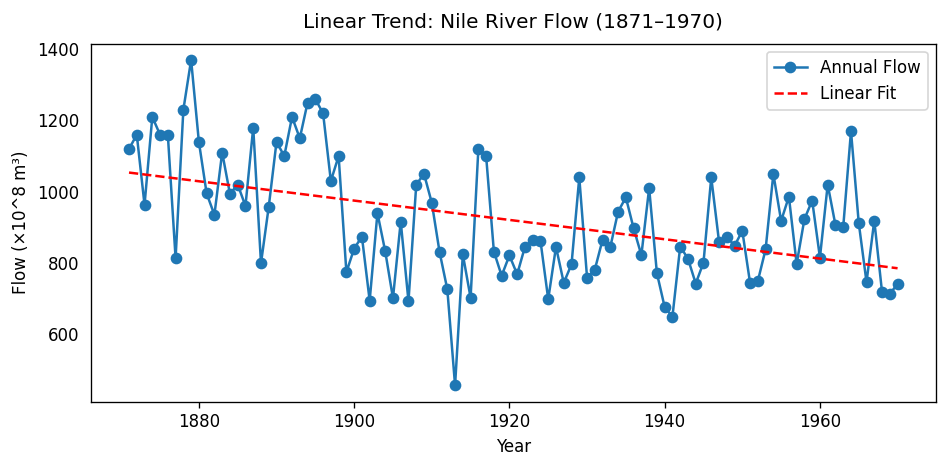

                            OLS Regression Results                            
Dep. Variable:                 volume   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     27.08
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           1.07e-06
Time:                        17:48:01   Log-Likelihood:                -642.31
No. Observations:                 100   AIC:                             1289.
Df Residuals:                      98   BIC:                             1294.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6132.1736   1001.758      6.121      0.0

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

# Load Nile River dataset (1871-1970)
nile = sm.datasets.nile.load_pandas().data
print(nile)
years_nile = nile['year']
flow_nile = nile['volume']

# Add a constant term for intercept (required by statsmodels)
X = sm.add_constant(years_nile)
model = sm.OLS(flow_nile, X).fit()  # Fit the linear regression model
linear_fit = model.predict(X)       # Get fitted values

# Plot the data and regression line
plt.figure(figsize=(8, 4))
plt.plot(years_nile, flow_nile, marker='o', linestyle='-', label='Annual Flow')
plt.plot(years_nile, linear_fit, linestyle='--', color='red', label='Linear Fit')
plt.title('Linear Trend: Nile River Flow (1871–1970)')
plt.xlabel('Year')
plt.ylabel('Flow (×10^8 m³)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print regression summary
print(model.summary())


# Print coefficient estimates and their standard errors
params = model.params        # intercept and slope
errors = model.bse           # standard errors of estimates

print("Coefficient estimates and standard errors:")
print(f"  Intercept (const): {params['const']:.4f} ± {errors['const']:.4f}")
print(f"  Slope (year):     {params['year']:.4f} ± {errors['year']:.4f}")

For Trend analysis we will make use of the var_group_df computed early

In [34]:
# Display var_group_df
var_group_df

,lat,lon,T2m
0,29.0,79.375,"[14.482349999999997, 18.493130000000008, 23.23..."
1,29.0,80.000,"[14.271299999999997, 18.06777, 22.866700000000..."
2,29.5,78.750,"[13.447080000000028, 17.157100000000014, 21.27..."
3,29.5,79.375,"[10.736379999999995, 13.711659999999997, 17.64..."
4,29.5,80.000,"[9.051720000000046, 11.70867000000004, 15.6457..."
...,...,...,...
93,36.0,76.250,"[-24.612979999999965, -21.47763999999998, -18...."
94,36.5,73.750,"[-16.592600000000004, -14.240849999999966, -9...."
95,36.5,74.375,"[-17.561669999999964, -15.41459999999995, -11...."
96,36.5,75.000,"[-19.73681999999997, -17.105169999999987, -13...."


In [35]:
# Display first row
display(var_group_df.iloc[0])

# Display cell content in the grouped column
display(var_group_df.iloc[0][var])
print(len(var_group_df.iloc[0][var]))

,0
lat,29.0
lon,79.375
T2m,"[14.482349999999997, 18.493130000000008, 23.23..."


array([14.48235, 18.49313, 23.23214, 31.37173, 35.4492 , 32.37396,
       28.7892 , 27.93743, 26.8997 , 24.0103 , 19.92492, 15.9823 ,
       14.8977 , 18.5135 , 22.82498, 30.01718, 33.677  , 34.86178,
       29.09017, 28.149  , 27.86205, 24.00222, 19.00277, 14.99633,
       15.09036, 15.72155, 20.4628 , 27.50424, 29.24276, 33.29318,
       32.22634, 28.2956 , 26.21334, 23.95327, 19.43508, 15.5227 ,
       13.8345 , 16.11248, 22.0386 , 26.40478, 32.06155, 33.954  ,
       32.5126 , 29.01153, 27.00802, 23.21752, 18.5733 , 15.06634,
       13.77215, 15.5963 , 24.68652, 30.38906, 35.2234 , 34.55984,
       31.10742, 30.13027, 25.23742, 23.9868 , 19.11355, 15.86428,
       14.67956, 17.9086 , 25.6573 , 30.26873, 34.04827, 34.11712,
       30.11608, 28.1097 , 26.11257, 21.65872, 17.62512, 15.2907 ,
       13.87603, 16.3422 , 22.4195 , 29.14498, 32.80255, 34.52252,
       29.97408, 28.8258 , 28.31027, 24.7072 , 20.51327, 15.50942,
       15.50112, 19.0245 , 24.19885, 29.60034, 31.18188, 36.21

528


## Install the pymannkendall library

In [36]:
# install the pymannkendall library for trend analysis
! pip install pymannkendall

##Import Required Library

In [37]:
# Trend analysis
import pymannkendall as mk

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import collections
import matplotlib.patches as mpatches
import calendar

## Mann-Kendall Test

Applying it for one location

In [38]:
# Check the ouput of the MK test function
array = var_group_df.iloc[0][var]
#original MK test
result = mk.original_test(array, alpha=0.05)
display(result)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.5471801210387246), z=np.float64(-0.6019910108324832), Tau=np.float64(-0.017530619285837504), s=np.float64(-2439.0), var_s=np.float64(16401644.333333334), slope=np.float64(-0.0010488981838194123), intercept=np.float64(26.041529671436432))

Applying for all grid points and getting the result

In [39]:
%%time
# Apply MK test rowwise and collect result into new column
var_group_df['result'] = var_group_df[var].apply(lambda x: mk.original_test(x, alpha=0.05))

var_group_df['trend'] = var_group_df['result'].apply(lambda x: x[0])
var_group_df['h'] = var_group_df['result'].apply(lambda x: x[1])
var_group_df['p'] = var_group_df['result'].apply(lambda x: x[2])
var_group_df['z'] = var_group_df['result'].apply(lambda x: x[3])
var_group_df['Tau'] = var_group_df['result'].apply(lambda x: x[4])
var_group_df['s'] = var_group_df['result'].apply(lambda x: x[5])
var_group_df['var_s'] = var_group_df['result'].apply(lambda x: x[6])
var_group_df['slope'] = var_group_df['result'].apply(lambda x: x[7]*12)
var_group_df['intercept'] = var_group_df['result'].apply(lambda x: x[8])

display(var_group_df)

,lat,lon,T2m,result,trend,h,p,z,Tau,s,var_s,slope,intercept
0,29.0,79.375,"[14.482349999999997, 18.493130000000008, 23.23...","(no trend, False, 0.5471801210387246, -0.60199...",no trend,False,0.547180,-0.601991,-0.017531,-2439.0,1.640164e+07,-0.012587,26.041530
1,29.0,80.000,"[14.271299999999997, 18.06777, 22.866700000000...","(no trend, False, 0.6120329307423509, -0.50717...",no trend,False,0.612033,-0.507174,-0.014771,-2055.0,1.640164e+07,-0.010246,25.475026
2,29.5,78.750,"[13.447080000000028, 17.157100000000014, 21.27...","(no trend, False, 0.8724887862987711, -0.16049...",no trend,False,0.872489,-0.160498,-0.004679,-651.0,1.640164e+07,-0.003060,24.844699
3,29.5,79.375,"[10.736379999999995, 13.711659999999997, 17.64...","(no trend, False, 0.8239441856712628, 0.222474...",no trend,False,0.823944,0.222475,0.006483,902.0,1.640165e+07,0.004188,20.822559
4,29.5,80.000,"[9.051720000000046, 11.70867000000004, 15.6457...","(no trend, False, 0.85095023718388, 0.18790613...",no trend,False,0.850950,0.187906,0.005477,762.0,1.640165e+07,0.003118,18.499660
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,36.0,76.250,"[-24.612979999999965, -21.47763999999998, -18....","(no trend, False, 0.44650513063904285, 0.76125...",no trend,False,0.446505,0.761254,0.022167,3084.0,1.640165e+07,0.018136,-12.220441
94,36.5,73.750,"[-16.592600000000004, -14.240849999999966, -9....","(no trend, False, 0.4339269406762196, 0.782489...",no trend,False,0.433927,0.782490,0.022785,3170.0,1.640165e+07,0.022600,-1.039836
95,36.5,74.375,"[-17.561669999999964, -15.41459999999995, -11....","(no trend, False, 0.43975161328357704, 0.77261...",no trend,False,0.439752,0.772613,0.022497,3130.0,1.640165e+07,0.020666,-3.016517
96,36.5,75.000,"[-19.73681999999997, -17.105169999999987, -13....","(no trend, False, 0.518156525476803, 0.6461896...",no trend,False,0.518157,0.646190,0.018817,2618.0,1.640165e+07,0.016533,-5.438527


CPU times: user 2.59 s, sys: 14.5 ms, total: 2.6 s
Wall time: 5.23 s


In [40]:
display(var_group_df['trend'].value_counts())

,count
trend,
no trend,98


### Plotting MK Test Results

Successfully loaded India shapefile from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp

Generating Plot Style (a) - Scatter Bg, Directional Marker Color...
Generated Z-statistic scatter background.
Generating Plot Style (b) - Scatter Bg, Directional Marker Color...
Generated Sen's slope scatter background.


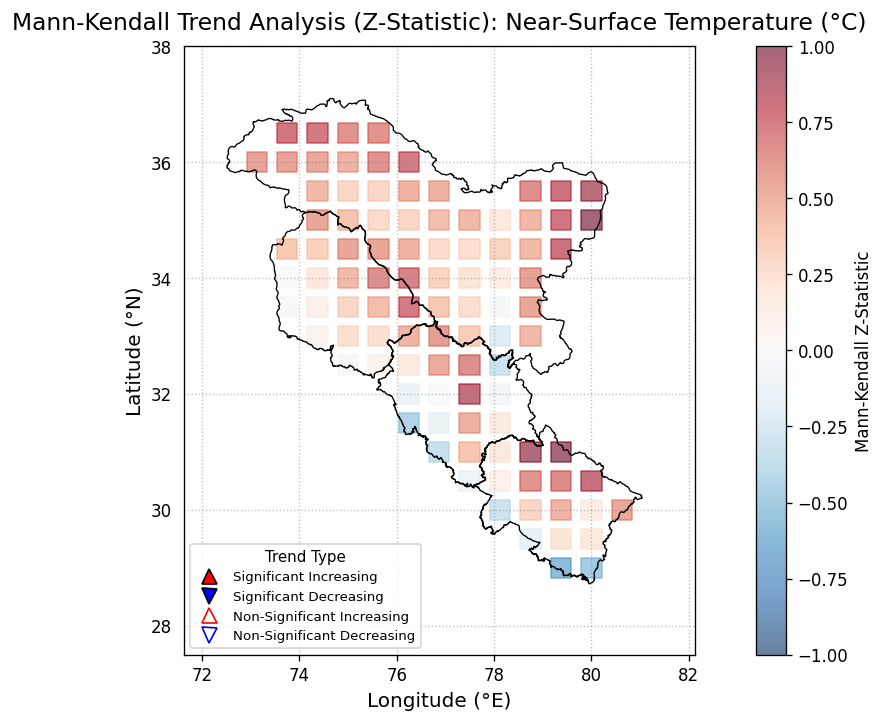

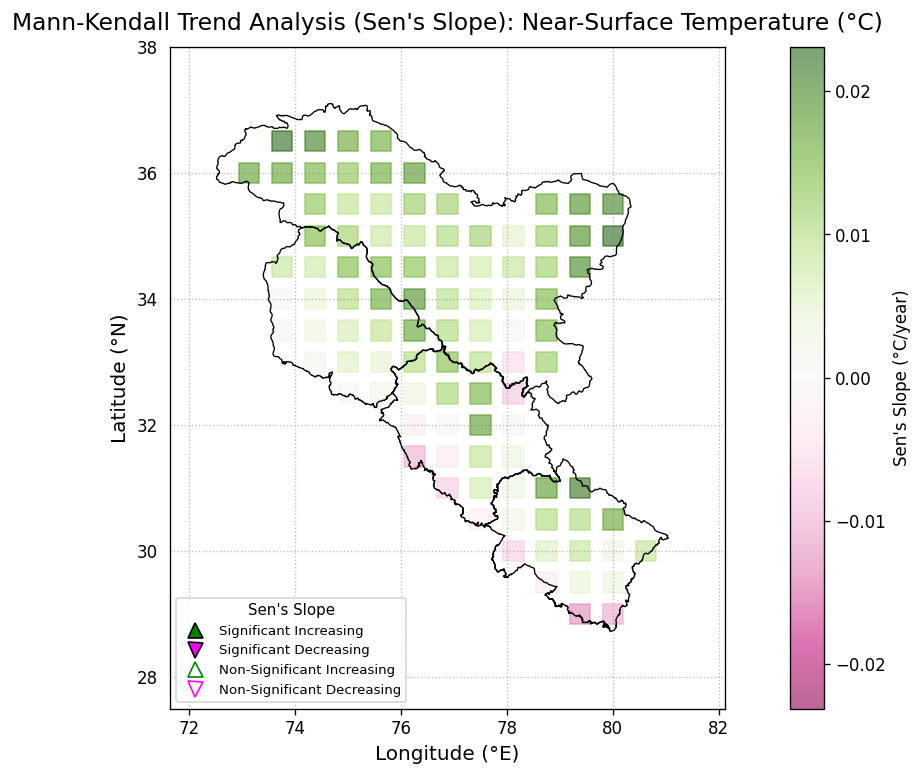


Finished generating plots.


In [41]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable # For colorbar placement
import matplotlib.colors as mcolors # For color normalization
import matplotlib.cm as cm # For colormaps and ScalarMappable
import os
# NOTE: Removed scipy.interpolate import as it's no longer needed

# --- Load India Shapefile ---
shapefile_path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp' # load path of shape file
india_shape = gpd.read_file(shapefile_path)
shapefile_loaded = True
india_shape = india_shape.to_crs(epsg=4326)
print(f"Successfully loaded India shapefile from {shapefile_path}")

# --- 1. Load your data ---
try:
    df = var_group_df.copy()
    df.reset_index(inplace=True)

except NameError:
    print("var_group_df not found, using dummy data.")

# --- Data Preprocessing ---
required_cols = ['lat', 'lon', 'z', 'slope', 'p', 'h', 'trend']
try:
    for col in required_cols:
        if col not in df.columns: raise KeyError(f"Required column '{col}' not found.")
        if col in ['lat', 'lon', 'z', 'slope', 'p']: df[col] = pd.to_numeric(df[col])
        elif col == 'h':
             if df[col].dtype != bool:
                 if df[col].isin([0, 1]).all(): df[col] = df[col].astype(bool)
                 elif df[col].astype(str).str.lower().isin(['true', 'false']).all(): df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})
                 else:
                      print(f"Warning: Col 'h' not bool. Assuming signif based on 'p'<0.05.")
                      df['p'] = pd.to_numeric(df['p'], errors='coerce')
                      df['h'] = df['p'] < 0.05
             df[col] = df[col].astype(bool)
except KeyError as e: print(f"Error: {e}"); exit()
except Exception as e: print(f"Error during data conversion: {e}"); exit()

try:
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
except Exception as e: print(f"Error creating GeoDataFrame: {e}"); exit()

cols_to_check = ['lon', 'lat', 'z', 'slope', 'p']
initial_rows = len(gdf)
gdf.dropna(subset=cols_to_check, inplace=True)
if len(gdf) < initial_rows: print(f"Warning: Dropped {initial_rows - len(gdf)} rows with NaNs.")
if gdf.empty: print("Error: DataFrame empty after NaN drop."); exit()

try:
    conditions = [ (gdf['h']==True)&(gdf['trend']=='increasing'), (gdf['h']==True)&(gdf['trend']=='decreasing'), (gdf['h']==False)&(gdf['trend']=='increasing'), (gdf['h']==False)&(gdf['trend']=='decreasing') ]
    choices = ['Sig Inc', 'Sig Dec', 'Non-Sig Inc', 'Non-Sig Dec']
    gdf['category'] = np.select(conditions, choices, default='No Trend')
except KeyError as e: print(f"Error categorizing: {e}"); exit()

# --- Plotting Setup ---
xmin, ymin, xmax, ymax = gdf.total_bounds
buffer = 1.5
plot_lon_min, plot_lon_max = xmin - buffer, xmax + buffer
plot_lat_min, plot_lat_max = ymin - buffer, ymax + buffer

# Colormaps for background scatter
cmap_z_name = 'RdBu_r'; cmap_z = plt.get_cmap(cmap_z_name)
cmap_slope_name = 'PiYG'; cmap_slope = plt.get_cmap(cmap_slope_name)

# Normalization for background scatter
z_max_abs = gdf['z'].abs().max(); z_max_abs = max(z_max_abs, 1.0)
norm_z = mcolors.Normalize(vmin=-z_max_abs, vmax=z_max_abs)
slope_max_abs = gdf['slope'].abs().max(); slope_max_abs = max(slope_max_abs, 1e-9)
norm_slope = mcolors.Normalize(vmin=-slope_max_abs, vmax=slope_max_abs)

# Marker Sizes (for triangles)
min_marker_size = 30; max_marker_size = 250; epsilon = 1e-9
if 'p' in gdf.columns and not gdf['p'].isna().all():
    inv_p = 1.0 / (gdf['p'] + epsilon); min_inv_p=inv_p.min(); max_inv_p=inv_p.max()
    norm_inv_p = (inv_p-min_inv_p)/(max_inv_p-min_inv_p) if max_inv_p>min_inv_p else 0.5
    gdf['marker_size_p'] = min_marker_size + norm_inv_p * (max_marker_size - min_marker_size)
else: gdf['marker_size_p'] = (min_marker_size + max_marker_size) / 2

if 'slope' in gdf.columns and not gdf['slope'].isna().all():
    abs_slope = gdf['slope'].abs(); min_abs_slope=abs_slope.min(); max_abs_slope=abs_slope.max()
    norm_abs_slope = (abs_slope-min_abs_slope)/(max_abs_slope-min_abs_slope) if max_abs_slope>min_abs_slope else 0.5
    gdf['marker_size_slope'] = min_marker_size + norm_abs_slope * (max_marker_size - min_marker_size)
else: gdf['marker_size_slope'] = (min_marker_size + max_marker_size) / 2

# --- Subsets for plotting ---
sig_inc = gdf[gdf['category'] == 'Sig Inc']
sig_dec = gdf[gdf['category'] == 'Sig Dec']
nonsig_inc = gdf[gdf['category'] == 'Non-Sig Inc']
nonsig_dec = gdf[gdf['category'] == 'Non-Sig Dec']

# --- Define Fixed Marker Colors (for triangles) ---
color_inc_z = 'red'    # For Z plot, increasing trend
color_dec_z = 'blue'   # For Z plot, decreasing trend
color_inc_s = 'green'  # For Slope plot, increasing trend
color_dec_s = 'magenta'# For Slope plot, decreasing trend
marker_edge_color = 'black' # Edge color for significant markers

# --- Legend Elements (Plot-Specific Colors for triangles) ---
legend_elements_z = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_z, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_z, markersize=9)
]
legend_elements_s = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_s, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_s, markersize=9)
]

# --- Scatter Background Parameters ---
base_marker_size = 150 # Size of the background points
base_alpha = 0.6       # Transparency of background points

# ===================================================================================
# Plot 1: Scatter Z Background, Directional Color Markers (Sized by P-val)
# ===================================================================================
print("\nGenerating Plot Style (a) - Scatter Bg, Directional Marker Color...")
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 7))
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
ax1.set_facecolor('white') # White background behind scatter if needed

# --- Plot Scatter Background (Z-Statistic) ---
try:
    sc_base_z = ax1.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['z'],              # Color by Z value
                           cmap=cmap_z, norm=norm_z,# Use Z colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Z-statistic scatter background.")
    # Colorbar represents the background scatter
    fig1.colorbar(sc_base_z, cax=cax1, label='Mann-Kendall Z-Statistic')
except Exception as e:
    print(f"Warning: Could not generate Z scatter background: {e}")
    ax1.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_z = cm.ScalarMappable(cmap=cmap_z, norm=norm_z); sm_z.set_array(gdf['z'])
    fig1.colorbar(sm_z, cax=cax1, label='Z-Statistic (Background Failed)')

# --- Plot Grid ---
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax1, color='black', linewidth=0.8, zorder=2) # Boundary above grid
#except Exception as e: print(f"Warning: Could not plot India boundary on Plot 1: {e}")

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
marker_alpha = 0.9 # Alpha for main markers
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax1.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_p'], facecolor='none', edgecolor=color_inc_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax1.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_p'], facecolor='none', edgecolor=color_dec_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax1.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_p'], c=color_inc_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax1.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_p'], c=color_dec_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax1.legend(handles=legend_elements_z, loc='lower left', title="Trend Type", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax1.set_title(f'Mann-Kendall Trend Analysis (Z-Statistic): {var_label}', fontsize=14, pad=10)
ax1.set_xlabel('Longitude (°E)', fontsize=12)
ax1.set_ylabel('Latitude (°N)', fontsize=12)
ax1.set_xlim(plot_lon_min, plot_lon_max)
ax1.set_ylim(plot_lat_min, plot_lat_max)

# ===================================================================================
# Plot 2: Scatter Slope Background, Directional Color Markers (Sized by Slope)
# ===================================================================================
print("Generating Plot Style (b) - Scatter Bg, Directional Marker Color...")
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 7))
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
ax2.set_facecolor('white')

# --- Plot Scatter Background (Sen's Slope) ---
try:
    sc_base_s = ax2.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['slope'],            # Color by Slope value
                           cmap=cmap_slope, norm=norm_slope,# Use Slope colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Sen's slope scatter background.")
    # Colorbar represents the background scatter
    if (var=="T2m"): units = "°C"
    else: units = ""
    slope_units = f"{units}/year"
    fig2.colorbar(sc_base_s, cax=cax2, label=f"Sen's Slope ({slope_units})")
except Exception as e:
    print(f"Warning: Could not generate Slope scatter background: {e}")
    ax2.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_slope = cm.ScalarMappable(cmap=cmap_slope, norm=norm_slope); sm_slope.set_array(gdf['slope'])
    if (var=="T2m"): units = "°C"
    else: units = "Unitless" if var != "T2m" else "Unknown"
    slope_units = f"{units}/month" if units != "Unitless" else "year⁻¹"
    fig2.colorbar(sm_slope, cax=cax2, label=f"Sen's Slope ({slope_units}) (Background Failed)")

# --- Plot Grid ---
ax2.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax2, color='black', linewidth=0.8, zorder=2) # Boundary above grid

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax2.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_slope'], facecolor='none', edgecolor=color_inc_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax2.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_slope'], facecolor='none', edgecolor=color_dec_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax2.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_slope'], c=color_inc_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax2.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_slope'], c=color_dec_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax2.legend(handles=legend_elements_s, loc='lower left', title="Sen's Slope", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax2.set_title(f"Mann-Kendall Trend Analysis (Sen's Slope): {var_label}", fontsize=14, pad=10)
ax2.set_xlabel('Longitude (°E)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_xlim(plot_lon_min, plot_lon_max)
ax2.set_ylim(plot_lat_min, plot_lat_max)

# --- Display and Save Plots ---
plt.tight_layout()

# --- Save Figures ---
# save_dir = f'/content/drive/MyDrive/Research Result/NWH_Trend Plots(Cloud_Data)(SMK-Test)/{var} Trend Plots_ScatterBg_DirMarkerColor' # Updated dir name
# os.makedirs(save_dir, exist_ok=True)
# print(f"\nAttempting to save figures to: {save_dir}")
# try:
#     fig1_path = os.path.join(save_dir, f'{var}_MK_Trend_Z_ScatterBg_DirColorPvalSize.png')
#     fig2_path = os.path.join(save_dir, f'{var}_MK_Trend_Slope_ScatterBg_DirColorSlopeSize.png')
#     fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
#     fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
#     print(f"Figures potentially saved.")
# except Exception as e:
#     print(f"Error saving figures: {e}")

plt.show()

print("\nFinished generating plots.")

##Applying Seasonal Mann-Kendall Test

### Applying for one location (for check)



In [42]:
# Check the ouput of the MK test function
array = var_group_df.iloc[0][var]
# Seasonal MK Test
result = mk.seasonal_test(array,period=12, alpha=0.05)
display(result)

Seasonal_Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.020753404553707222), z=np.float64(-2.312440792731126), Tau=np.float64(-0.06985553206483439), s=np.float64(-793.0), var_s=np.float64(117302.99999999999), slope=np.float64(-0.009290489766081395), intercept=np.float64(25.969148671113555))

### Applying for all available grid points

In [43]:
%%time
# Apply Seasonal-MK test rowwise and collect result into new column
var_group_df['result'] = var_group_df[var].apply(lambda x: mk.seasonal_test(x,period=12, alpha=0.05))

var_group_df['trend'] = var_group_df['result'].apply(lambda x: x[0])
var_group_df['h'] = var_group_df['result'].apply(lambda x: x[1])
var_group_df['p'] = var_group_df['result'].apply(lambda x: x[2])
var_group_df['z'] = var_group_df['result'].apply(lambda x: x[3])
var_group_df['Tau'] = var_group_df['result'].apply(lambda x: x[4])
var_group_df['s'] = var_group_df['result'].apply(lambda x: x[5])
var_group_df['var_s'] = var_group_df['result'].apply(lambda x: x[6])
var_group_df['slope'] = var_group_df['result'].apply(lambda x: x[7]*12)
var_group_df['intercept'] = var_group_df['result'].apply(lambda x: x[8])


display(var_group_df)

,lat,lon,T2m,result,trend,h,p,z,Tau,s,var_s,slope,intercept
0,29.0,79.375,"[14.482349999999997, 18.493130000000008, 23.23...","(decreasing, True, 0.020753404553707222, -2.31...",decreasing,True,0.020753,-2.312441,-0.069856,-793.0,117303.0,-0.111486,25.969149
1,29.0,80.000,"[14.271299999999997, 18.06777, 22.866700000000...","(no trend, False, 0.26220979795737254, -1.1211...",no trend,False,0.262210,-1.121183,-0.033915,-385.0,117303.0,-0.053116,25.347235
2,29.5,78.750,"[13.447080000000028, 17.157100000000014, 21.27...","(no trend, False, 0.8655249584773275, -0.16934...",no trend,False,0.865525,-0.169345,-0.005197,-59.0,117303.0,-0.006458,24.789317
3,29.5,79.375,"[10.736379999999995, 13.711659999999997, 17.64...","(increasing, True, 0.026686047878198726, 2.216...",increasing,True,0.026686,2.216080,0.066949,760.0,117304.0,0.096343,20.738235
4,29.5,80.000,"[9.051720000000046, 11.70867000000004, 15.6457...","(increasing, True, 0.011744415141645481, 2.519...",increasing,True,0.011744,2.519732,0.076110,864.0,117304.0,0.100588,18.384063
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,36.0,76.250,"[-24.612979999999965, -21.47763999999998, -18....","(increasing, True, 0.00010684835675833781, 3.8...",increasing,True,0.000107,3.874490,0.116984,1328.0,117304.0,0.192150,-12.173808
94,36.5,73.750,"[-16.592600000000004, -14.240849999999966, -9....","(increasing, True, 0.0003181749304868031, 3.60...",increasing,True,0.000318,3.600035,0.108703,1234.0,117304.0,0.216951,-0.940575
95,36.5,74.375,"[-17.561669999999964, -15.41459999999995, -11....","(increasing, True, 0.0002716752244924514, 3.64...",increasing,True,0.000272,3.640911,0.109937,1248.0,117304.0,0.196444,-2.922196
96,36.5,75.000,"[-19.73681999999997, -17.105169999999987, -13....","(increasing, True, 0.0025117128557550217, 3.02...",increasing,True,0.002512,3.021927,0.091261,1036.0,117304.0,0.164878,-5.377188


CPU times: user 1.32 s, sys: 32.2 ms, total: 1.36 s
Wall time: 1.34 s


In [44]:
display(var_group_df['trend'].value_counts())

,count
trend,
increasing,49
no trend,47
decreasing,2


### Plotting MK Test Results

Successfully loaded India shapefile from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp

Generating Plot Style (a) - Scatter Bg, Directional Marker Color...
Generated Z-statistic scatter background.
Generating Plot Style (b) - Scatter Bg, Directional Marker Color...
Generated Sen's slope scatter background.


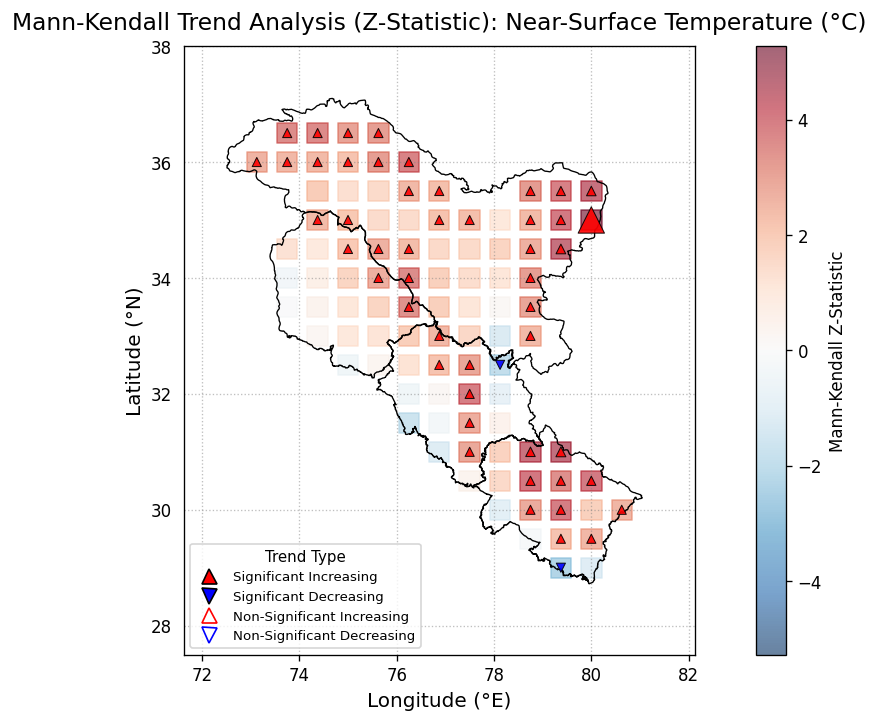

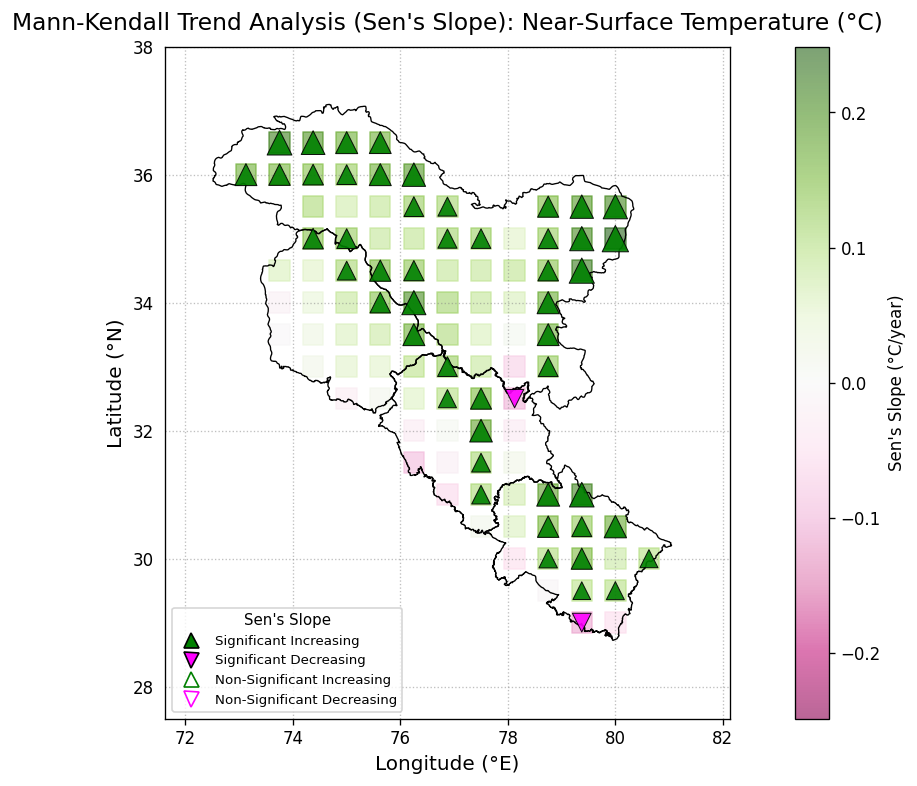


Finished generating plots.


In [45]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable # For colorbar placement
import matplotlib.colors as mcolors # For color normalization
import matplotlib.cm as cm # For colormaps and ScalarMappable
import os
# NOTE: Removed scipy.interpolate import as it's no longer needed

# --- Load India Shapefile ---
shapefile_path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp' # load path of shape file
india_shape = gpd.read_file(shapefile_path)
shapefile_loaded = True
india_shape = india_shape.to_crs(epsg=4326)
print(f"Successfully loaded India shapefile from {shapefile_path}")

# --- 1. Load your data ---
try:
    df = var_group_df.copy()
    df.reset_index(inplace=True)

except NameError:
    print("var_group_df not found, using dummy data.")

# --- Data Preprocessing ---
required_cols = ['lat', 'lon', 'z', 'slope', 'p', 'h', 'trend']
try:
    for col in required_cols:
        if col not in df.columns: raise KeyError(f"Required column '{col}' not found.")
        if col in ['lat', 'lon', 'z', 'slope', 'p']: df[col] = pd.to_numeric(df[col])
        elif col == 'h':
             if df[col].dtype != bool:
                 if df[col].isin([0, 1]).all(): df[col] = df[col].astype(bool)
                 elif df[col].astype(str).str.lower().isin(['true', 'false']).all(): df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})
                 else:
                      print(f"Warning: Col 'h' not bool. Assuming signif based on 'p'<0.05.")
                      df['p'] = pd.to_numeric(df['p'], errors='coerce')
                      df['h'] = df['p'] < 0.05
             df[col] = df[col].astype(bool)
except KeyError as e: print(f"Error: {e}"); exit()
except Exception as e: print(f"Error during data conversion: {e}"); exit()

try:
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
except Exception as e: print(f"Error creating GeoDataFrame: {e}"); exit()

cols_to_check = ['lon', 'lat', 'z', 'slope', 'p']
initial_rows = len(gdf)
gdf.dropna(subset=cols_to_check, inplace=True)
if len(gdf) < initial_rows: print(f"Warning: Dropped {initial_rows - len(gdf)} rows with NaNs.")
if gdf.empty: print("Error: DataFrame empty after NaN drop."); exit()

try:
    conditions = [ (gdf['h']==True)&(gdf['trend']=='increasing'), (gdf['h']==True)&(gdf['trend']=='decreasing'), (gdf['h']==False)&(gdf['trend']=='increasing'), (gdf['h']==False)&(gdf['trend']=='decreasing') ]
    choices = ['Sig Inc', 'Sig Dec', 'Non-Sig Inc', 'Non-Sig Dec']
    gdf['category'] = np.select(conditions, choices, default='No Trend')
except KeyError as e: print(f"Error categorizing: {e}"); exit()

# --- Plotting Setup ---
xmin, ymin, xmax, ymax = gdf.total_bounds
buffer = 1.5
plot_lon_min, plot_lon_max = xmin - buffer, xmax + buffer
plot_lat_min, plot_lat_max = ymin - buffer, ymax + buffer

# Colormaps for background scatter
cmap_z_name = 'RdBu_r'; cmap_z = plt.get_cmap(cmap_z_name)
cmap_slope_name = 'PiYG'; cmap_slope = plt.get_cmap(cmap_slope_name)

# Normalization for background scatter
z_max_abs = gdf['z'].abs().max(); z_max_abs = max(z_max_abs, 1.0)
norm_z = mcolors.Normalize(vmin=-z_max_abs, vmax=z_max_abs)
slope_max_abs = gdf['slope'].abs().max(); slope_max_abs = max(slope_max_abs, 1e-9)
norm_slope = mcolors.Normalize(vmin=-slope_max_abs, vmax=slope_max_abs)

# Marker Sizes (for triangles)
min_marker_size = 30; max_marker_size = 250; epsilon = 1e-9
if 'p' in gdf.columns and not gdf['p'].isna().all():
    inv_p = 1.0 / (gdf['p'] + epsilon); min_inv_p=inv_p.min(); max_inv_p=inv_p.max()
    norm_inv_p = (inv_p-min_inv_p)/(max_inv_p-min_inv_p) if max_inv_p>min_inv_p else 0.5
    gdf['marker_size_p'] = min_marker_size + norm_inv_p * (max_marker_size - min_marker_size)
else: gdf['marker_size_p'] = (min_marker_size + max_marker_size) / 2

if 'slope' in gdf.columns and not gdf['slope'].isna().all():
    abs_slope = gdf['slope'].abs(); min_abs_slope=abs_slope.min(); max_abs_slope=abs_slope.max()
    norm_abs_slope = (abs_slope-min_abs_slope)/(max_abs_slope-min_abs_slope) if max_abs_slope>min_abs_slope else 0.5
    gdf['marker_size_slope'] = min_marker_size + norm_abs_slope * (max_marker_size - min_marker_size)
else: gdf['marker_size_slope'] = (min_marker_size + max_marker_size) / 2

# --- Subsets for plotting ---
sig_inc = gdf[gdf['category'] == 'Sig Inc']
sig_dec = gdf[gdf['category'] == 'Sig Dec']
nonsig_inc = gdf[gdf['category'] == 'Non-Sig Inc']
nonsig_dec = gdf[gdf['category'] == 'Non-Sig Dec']

# --- Define Fixed Marker Colors (for triangles) ---
color_inc_z = 'red'    # For Z plot, increasing trend
color_dec_z = 'blue'   # For Z plot, decreasing trend
color_inc_s = 'green'  # For Slope plot, increasing trend
color_dec_s = 'magenta'# For Slope plot, decreasing trend
marker_edge_color = 'black' # Edge color for significant markers

# --- Legend Elements (Plot-Specific Colors for triangles) ---
legend_elements_z = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_z, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_z, markersize=9)
]
legend_elements_s = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_s, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_s, markersize=9)
]

# --- Scatter Background Parameters ---
base_marker_size = 150 # Size of the background points
base_alpha = 0.6       # Transparency of background points

# ===================================================================================
# Plot 1: Scatter Z Background, Directional Color Markers (Sized by P-val)
# ===================================================================================
print("\nGenerating Plot Style (a) - Scatter Bg, Directional Marker Color...")
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 7))
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
ax1.set_facecolor('white') # White background behind scatter if needed

# --- Plot Scatter Background (Z-Statistic) ---
try:
    sc_base_z = ax1.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['z'],              # Color by Z value
                           cmap=cmap_z, norm=norm_z,# Use Z colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Z-statistic scatter background.")
    # Colorbar represents the background scatter
    fig1.colorbar(sc_base_z, cax=cax1, label='Mann-Kendall Z-Statistic')
except Exception as e:
    print(f"Warning: Could not generate Z scatter background: {e}")
    ax1.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_z = cm.ScalarMappable(cmap=cmap_z, norm=norm_z); sm_z.set_array(gdf['z'])
    fig1.colorbar(sm_z, cax=cax1, label='Z-Statistic (Background Failed)')

# --- Plot Grid ---
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax1, color='black', linewidth=0.8, zorder=2) # Boundary above grid
#except Exception as e: print(f"Warning: Could not plot India boundary on Plot 1: {e}")

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
marker_alpha = 0.9 # Alpha for main markers
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax1.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_p'], facecolor='none', edgecolor=color_inc_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax1.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_p'], facecolor='none', edgecolor=color_dec_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax1.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_p'], c=color_inc_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax1.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_p'], c=color_dec_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax1.legend(handles=legend_elements_z, loc='lower left', title="Trend Type", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax1.set_title(f'Mann-Kendall Trend Analysis (Z-Statistic): {var_label}', fontsize=14, pad=10)
ax1.set_xlabel('Longitude (°E)', fontsize=12)
ax1.set_ylabel('Latitude (°N)', fontsize=12)
ax1.set_xlim(plot_lon_min, plot_lon_max)
ax1.set_ylim(plot_lat_min, plot_lat_max)

# ===================================================================================
# Plot 2: Scatter Slope Background, Directional Color Markers (Sized by Slope)
# ===================================================================================
print("Generating Plot Style (b) - Scatter Bg, Directional Marker Color...")
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 7))
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
ax2.set_facecolor('white')

# --- Plot Scatter Background (Sen's Slope) ---
try:
    sc_base_s = ax2.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['slope'],            # Color by Slope value
                           cmap=cmap_slope, norm=norm_slope,# Use Slope colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Sen's slope scatter background.")
    # Colorbar represents the background scatter
    if (var=="T2m"): units = "°C"
    else: units = ""
    slope_units = f"{units}/year"
    fig2.colorbar(sc_base_s, cax=cax2, label=f"Sen's Slope ({slope_units})")
except Exception as e:
    print(f"Warning: Could not generate Slope scatter background: {e}")
    ax2.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_slope = cm.ScalarMappable(cmap=cmap_slope, norm=norm_slope); sm_slope.set_array(gdf['slope'])
    if (var=="T2m"): units = "°C"
    else: units = "Unitless" if var != "T2m" else "Unknown"
    slope_units = f"{units}/month" if units != "Unitless" else "year⁻¹"
    fig2.colorbar(sm_slope, cax=cax2, label=f"Sen's Slope ({slope_units}) (Background Failed)")

# --- Plot Grid ---
ax2.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax2, color='black', linewidth=0.8, zorder=2) # Boundary above grid

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax2.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_slope'], facecolor='none', edgecolor=color_inc_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax2.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_slope'], facecolor='none', edgecolor=color_dec_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax2.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_slope'], c=color_inc_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax2.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_slope'], c=color_dec_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax2.legend(handles=legend_elements_s, loc='lower left', title="Sen's Slope", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax2.set_title(f"Mann-Kendall Trend Analysis (Sen's Slope): {var_label}", fontsize=14, pad=10)
ax2.set_xlabel('Longitude (°E)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_xlim(plot_lon_min, plot_lon_max)
ax2.set_ylim(plot_lat_min, plot_lat_max)

# --- Display and Save Plots ---
plt.tight_layout()

# --- Save Figures ---
# save_dir = f'/content/drive/MyDrive/Research Result/NWH_Trend Plots(Cloud_Data)(SMK-Test)/{var} Trend Plots_ScatterBg_DirMarkerColor' # Updated dir name
# os.makedirs(save_dir, exist_ok=True)
# print(f"\nAttempting to save figures to: {save_dir}")
# try:
#     fig1_path = os.path.join(save_dir, f'{var}_MK_Trend_Z_ScatterBg_DirColorPvalSize.png')
#     fig2_path = os.path.join(save_dir, f'{var}_MK_Trend_Slope_ScatterBg_DirColorSlopeSize.png')
#     fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
#     fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
#     print(f"Figures potentially saved.")
# except Exception as e:
#     print(f"Error saving figures: {e}")

plt.show()

print("\nFinished generating plots.")

# TASK 5: MORAN'S I

## Install esda and cartopy libraries

In [46]:
# install required libraries
! pip install esda
! pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 101.2 MB/s eta 0:00:00


## Import the Data from csv file named T2m_time_series

In [47]:
# Data used for this Near-surface Temperature
df = pd.read_csv('https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module2/Data/T2m_time_series.csv') # Replace with your own csv file path

##Display data head

In [48]:
# display head of df
df.head()

,lat,lon,1980-01,1980-02,1980-03,1980-04,1980-05,1980-06,1980-07,1980-08,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,28.0,70.000,15.15292,19.52694,23.43853,33.14645,36.66960,38.73010,37.63085,35.50765,...,25.89590,29.34347,33.21810,35.83860,35.17983,33.91810,34.67380,29.79675,23.28414,18.14126
1,28.0,70.625,14.90194,19.22790,23.09646,33.01418,36.37985,38.36060,36.86540,34.98904,...,25.75823,29.57740,33.22756,35.23205,34.50784,33.60380,34.22350,29.60864,22.87057,17.77172
2,28.0,71.250,14.77535,19.20934,23.04202,32.95257,36.22332,38.28246,36.24392,34.66387,...,25.82660,29.87664,33.20352,34.80706,33.88995,33.38662,34.11215,29.56368,22.70930,17.67132
3,28.0,71.875,14.67030,19.27014,23.10140,32.84100,36.06054,38.19940,35.92416,34.57420,...,25.78770,29.92684,33.08462,34.41384,33.48766,33.24923,33.75695,29.41720,22.53735,17.67773
4,28.0,72.500,14.48070,19.17925,22.98830,32.52392,35.66735,37.83080,35.38430,34.29220,...,25.44030,29.67877,32.75106,33.99480,32.93630,32.80730,33.04458,28.98956,22.16177,17.48058


Shapefile CRS is 'EPSG:3857'. Converting to 'EPSG:4326'.
Processing Local Moran's I for 1980-01...


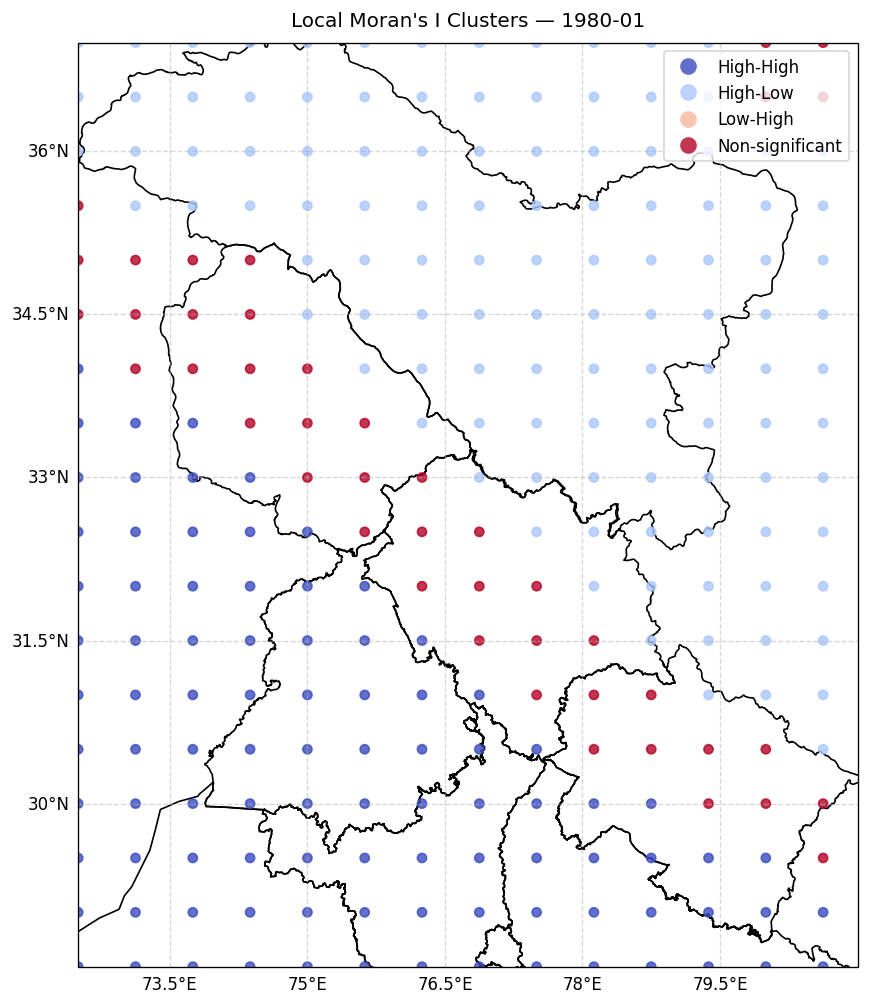

In [49]:
import pandas as pd
import geopandas as gpd
import numpy as np
import libpysal as lps
import esda
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import box
import os

# --- Step 1: Load Data ---
try:
    df = pd.read_csv('https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module2/Data/T2m_time_series.csv')
except FileNotFoundError:
    print("CSV file not found. Using dummy data for demonstration.")
    data = {'lat': np.random.uniform(28.5, 37, 100), 'lon': np.random.uniform(72.5, 81, 100), '2023-01-01': np.random.uniform(273, 293, 100)}
    df = pd.DataFrame(data)

# --- Step 2: Load and Fix Shapefile ---
try:
    shapefile_path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/India_Boundary_Files/India_State_Boundary.shp'
    gdf = gpd.read_file(shapefile_path)

    # --- CRS CHECKING AND FIXING BLOCK ---
    # This automatically detects that your CRS is EPSG:3857 and converts it
    expected_crs = "EPSG:4326" # WGS 84, matches ccrs.PlateCarree()

    if gdf.crs is None:
        print(f"Shapefile CRS is missing. Setting to {expected_crs}. \nWARNING: Assumes data is in WGS 84 lat/lon.")
        gdf = gdf.set_crs(expected_crs)

    if str(gdf.crs) != expected_crs: # Using str() for safer comparison
        print(f"Shapefile CRS is '{gdf.crs}'. Converting to '{expected_crs}'.")
        gdf = gdf.to_crs(expected_crs) # THIS IS THE KEY FIX
    # --- END CRS BLOCK ---

except Exception as e:
    print(f"Could not load shapefile: {e}. Using a dummy bounding box for demonstration.")
    gdf = gpd.GeoDataFrame(geometry=[box(72.5, 28.5, 81, 37)], crs="EPSG:4326")

# --- Step 3: Create GeoDataFrame for temperature points ---
df = df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})
locations = gpd.GeoDataFrame(
    df[['latitude', 'longitude']],
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs=gdf.crs # Inherit the now-corrected CRS
)

# --- Step 4: Spatial Analysis Loop ---
date_columns = df.columns[2:]

for date in date_columns:
    print(f"Processing Local Moran's I for {date}...")

    gdf1 = locations.copy()
    gdf1['Near-Surface Temperature'] = df[date].values

    w = lps.weights.KNN.from_dataframe(gdf1, k=8)
    w.transform = "r"

    y = gdf1['Near-Surface Temperature'].values
    lm = esda.Moran_Local(y, w)
    gdf1['local_moran'] = lm.Is
    gdf1['p_value']     = lm.p_sim

    sig = gdf1['p_value'] < 0.05
    gdf1['cluster'] = 'Non-significant'
    gdf1.loc[sig & (lm.q == 1), 'cluster'] = 'High-High'
    gdf1.loc[sig & (lm.q == 2), 'cluster'] = 'Low-Low'
    gdf1.loc[sig & (lm.q == 3), 'cluster'] = 'High-Low'
    gdf1.loc[sig & (lm.q == 4), 'cluster'] = 'Low-High'

    # --- Step 5: Plotting ---
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    map_extent = [72.5, 81, 28.5, 37]
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    gdf.plot(
        ax=ax,
        facecolor='none',
        edgecolor='black',
        linewidth=1.0,
        transform=ccrs.PlateCarree()
    )

    gdf1.plot(
        column='cluster',
        categorical=True,
        cmap='coolwarm',
        legend=True,
        ax=ax,
        markersize=30,
        alpha=0.8,
        transform=ccrs.PlateCarree()
    )

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f"Local Moran's I Clusters — {date}")

    os.makedirs("output_images", exist_ok=True)
    plt.savefig(f"output_images/morans_{date}.png")
    plt.show()
    break #( uncomment if want for all dates)